# Imports

In [ ]:
import os
import json
import joblib
import warnings
import optuna
from optuna.samplers import TPESampler

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor

from scipy import stats
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
OUTPUT_DIR = "./output_within_group_holdout"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use("default")
sns.set_theme(style="whitegrid")


# 1. Data Loading

In [ ]:
data = pd.read_csv(
    "calix_database_full.csv",
    sep=";",
    encoding="cp1251",
    decimal=","
)

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (263, 27)


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
0,Group 1,1.log,6.0.0,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,28-12-14-15,21-22-24-25,43-3-5-41,35-7-9-34,-0.308,0.498,...,2.590703366,2.478,-2007.777943398343,-139.177613,-6.030502,-0.610805,5.419776172200001,-9.9169,-6.0708,3.846091
1,Group 1,2.log,6.0.0,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...,32-5-3-34,22-21-19-18,15-14-12-25,28-9-7-29,0.137,-0.620,...,3.535005031,10.409,-11671.72278906903,-102.835983,-6.500109,-1.218862,5.281324569000001,-10.8366,-7.3075,3.529071
2,Group 1,3.log,6.0.0,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...,22-23-25-96,98-28-30-31,37-38-40-41,47-48-50-51,1.669,162.334,...,0.07467472,0.028,-4015.554962182609,-278.371600,-5.954284,-0.580329,5.3740338088,-9.8131,-5.9846,3.828526
3,Group 1,4.log,6.0.0,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...,25-24-22-21,15-14-12-28,34-9-7-35,41-5-3-43,-3.282,3.904,...,6.794153481,8.595,-3442.525320095948,-139.464044,-6.460735,-1.185202,5.275610175000001,-9.8855,-7.0091,2.876384
4,Group 1,5.log,6.0.0,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...,17-7-9-16,14-12-29-30,32-26-24-23,21-3-5-19,-7.535,7.358,...,5.052353374,6.307,-2814.661638889585,-88.794873,-6.772791,-1.283951,5.4889203396,-10.1069,-7.2734,2.833483


In [137]:
print(data.dtypes)

Folder                    object
File                      object
Program Version           object
SMILES                    object
Atoms_1                   object
Atoms_2                   object
Atoms_3                   object
Atoms_4                   object
dihedral_1_orca          float64
dihedral_2_orca          float64
dihedral_3_orca          float64
dihedral_4_orca          float64
dihedral_1_xtb           float64
dihedral_2_xtb           float64
dihedral_3_xtb           float64
dihedral_4_xtb           float64
Number of Atoms            int64
Magnitude (Debye)         object
Dipole_xtb (Debye)       float64
Final Energy (Eh)         object
Total energy xtb (Eh)    float64
HOMO_orca (eV)           float64
LUMO_orca (eV)           float64
HOMO-LUMO Gap (eV)        object
HOMO_xtb (eV)            float64
LUMO_xtb (eV)            float64
HOMO-LUMO xtb (eV)       float64
dtype: object


## 1.1 Numeric conversion

In [138]:

numeric_cols = [
    "dihedral_1_orca",
    "dihedral_2_orca",
    "dihedral_3_orca",
    "dihedral_4_orca",
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
    "Number of Atoms",
    "Magnitude (Debye)",
    "Dipole_xtb (Debye)",
    "Final Energy (Eh)",
    "Total energy xtb (Eh)",
    "HOMO_orca (eV)",
    "LUMO_orca (eV)",
    "HOMO-LUMO Gap (eV)",
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_summary = data[numeric_cols].isna().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

data[data[numeric_cols].isna().any(axis=1)].head()


dihedral_1_orca    15
dihedral_3_orca    15
dihedral_4_orca    15
dihedral_1_xtb     15
dihedral_2_xtb     15
dihedral_3_xtb     15
dihedral_4_xtb     15
dihedral_2_orca    15
dtype: int64


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
75,Group 7,72.log,6.0.0,OC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.199178,11.289,-850.946504,-51.096075,-6.699321,-2.911332,3.788045,-9.8632,-9.0211,0.842072
76,Group 7,73.log,6.0.0,OCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.178044,11.346,-1043.736047,-64.642234,-6.632055,-2.889727,3.742384,-9.8054,-8.9571,0.848376
77,Group 7,74.log,6.0.0,CCCCCCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=...,NaN,NaN,NaN,NaN,NaN,NaN,...,8.183655,12.713,-1164.858230,-76.409827,-6.581987,-2.856937,3.725105,-9.7315,-8.9131,0.818400
78,Group 7,75.log,6.0.0,OCCN(CC)C(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O...,NaN,NaN,NaN,NaN,NaN,NaN,...,9.143029,14.413,-1063.148583,-67.186200,-5.985930,-2.711222,3.274756,-9.4801,-8.6633,0.816793
112,Group 9,109.log,6.0.0,CC(C)(C)C(C=C1)=CC=C1OCC2=N3N([H][N]4C(COC5=CC...,NaN,NaN,NaN,NaN,NaN,NaN,...,2.149567,2.000,-3832.915063,-255.867584,-5.876433,-0.957637,4.918869,-9.9602,-6.9416,3.018645


## 1.2 Feature engineering

In [139]:
dihedral_cols = [
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
]

for col in dihedral_cols:
    # флаг наличия угла оставляем
    data[col + "_exists"] = data[col].notna().astype(int)

    # сначала считаем sin/cos только там, где угол есть
    angle_rad = np.deg2rad(data[col])
    data[col + "_sin"] = np.sin(angle_rad)
    data[col + "_cos"] = np.cos(angle_rad)

    # для строк, где угла нет, явно ставим sin=0, cos=1
    missing_mask = data[col].isna()
    data.loc[missing_mask, col + "_sin"] = 0.0
    data.loc[missing_mask, col + "_cos"] = 1.0

data["delta_homo"] = data["HOMO_orca (eV)"] - data["HOMO_xtb (eV)"]
data["delta_lumo"] = data["LUMO_orca (eV)"] - data["LUMO_xtb (eV)"]
data["delta_energy_per_atom"] = (data["Final Energy (Eh)"] - data["Total energy xtb (Eh)"]) / data["Number of Atoms"]
data["delta_energy"] = data["Final Energy (Eh)"] - data["Total energy xtb (Eh)"]

# Additional informative descriptors derived from xTB outputs
data["energy_xtb_per_atom"] = data["Total energy xtb (Eh)"] / data["Number of Atoms"]
data["dipole_xtb_per_atom"] = data["Dipole_xtb (Debye)"] / data["Number of Atoms"]
data["abs_homo_xtb"] = data["HOMO_xtb (eV)"].abs()
data["abs_lumo_xtb"] = data["LUMO_xtb (eV)"].abs()

data[[
    "delta_homo",
    "delta_lumo",
    "delta_energy",
    "delta_energy_per_atom",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom"
]].describe()


,delta_homo,delta_lumo,delta_energy,delta_energy_per_atom,energy_xtb_per_atom,dipole_xtb_per_atom
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,3.746623,5.906302,-6252.593112,-38.944753,-1.493317,0.041898
std,0.207559,0.328102,4570.612673,32.967615,0.185042,0.052855
min,2.898414,2.832077,-18720.762656,-270.903247,-2.437544,0.000000
25%,3.663266,5.805176,-6712.123116,-33.731456,-1.506053,0.011110
50%,3.767514,5.911925,-4667.156598,-31.042624,-1.452245,0.026485
75%,3.863822,6.000838,-3653.093406,-24.713211,-1.414107,0.053625
max,4.370895,6.831011,-765.674339,-17.080677,-1.267910,0.418111


# 2. Exploratory Data Analysis (EDA)

## 2.1 95% confidence intervals for targets

In [140]:

target_cols = ["delta_homo", "delta_lumo", "delta_energy_per_atom", "delta_energy"]

metrics = {}

for feature in target_cols:
    mean = data[feature].mean()
    std_dev = data[feature].std()
    n = len(data)
    std_error = std_dev / np.sqrt(n)
    z_score = stats.norm.ppf(0.975)
    margin_of_error = z_score * std_error

    metrics[feature] = {
        "mean": mean,
        "std": std_dev,
        "95% CI Lower": mean - margin_of_error,
        "95% CI Upper": mean + margin_of_error,
        "95% CI Width": 2 * margin_of_error
    }

ci_df = pd.DataFrame(metrics).T
ci_df


,mean,std,95% CI Lower,95% CI Upper,95% CI Width
delta_homo,3.746623,0.207559,3.721538,3.771708,0.050170
delta_lumo,5.906302,0.328102,5.866648,5.945955,0.079306
delta_energy_per_atom,-38.944753,32.967615,-42.929106,-34.960401,7.968705
delta_energy,-6252.593112,4570.612673,-6804.981622,-5700.204603,1104.777019


## 2.2 Baseline xTB vs ORCA correlations

In [141]:

print("HOMO baseline correlation")
print(data[["HOMO_xtb (eV)", "HOMO_orca (eV)"]].corr())
print()
print("LUMO baseline correlation")
print(data[["LUMO_xtb (eV)", "LUMO_orca (eV)"]].corr())
print()
print("Final energy baseline correlation")
print(data[["Total energy xtb (Eh)", "Final Energy (Eh)"]].corr())


HOMO baseline correlation
                HOMO_xtb (eV)  HOMO_orca (eV)
HOMO_xtb (eV)        1.000000        0.861542
HOMO_orca (eV)       0.861542        1.000000

LUMO baseline correlation
                LUMO_xtb (eV)  LUMO_orca (eV)
LUMO_xtb (eV)          1.0000          0.9076
LUMO_orca (eV)         0.9076          1.0000

Final energy baseline correlation
                       Total energy xtb (Eh)  Final Energy (Eh)
Total energy xtb (Eh)               1.000000           0.817974
Final Energy (Eh)                   0.817974           1.000000


## 2.3 Scatter plots of xTB features vs target deltas

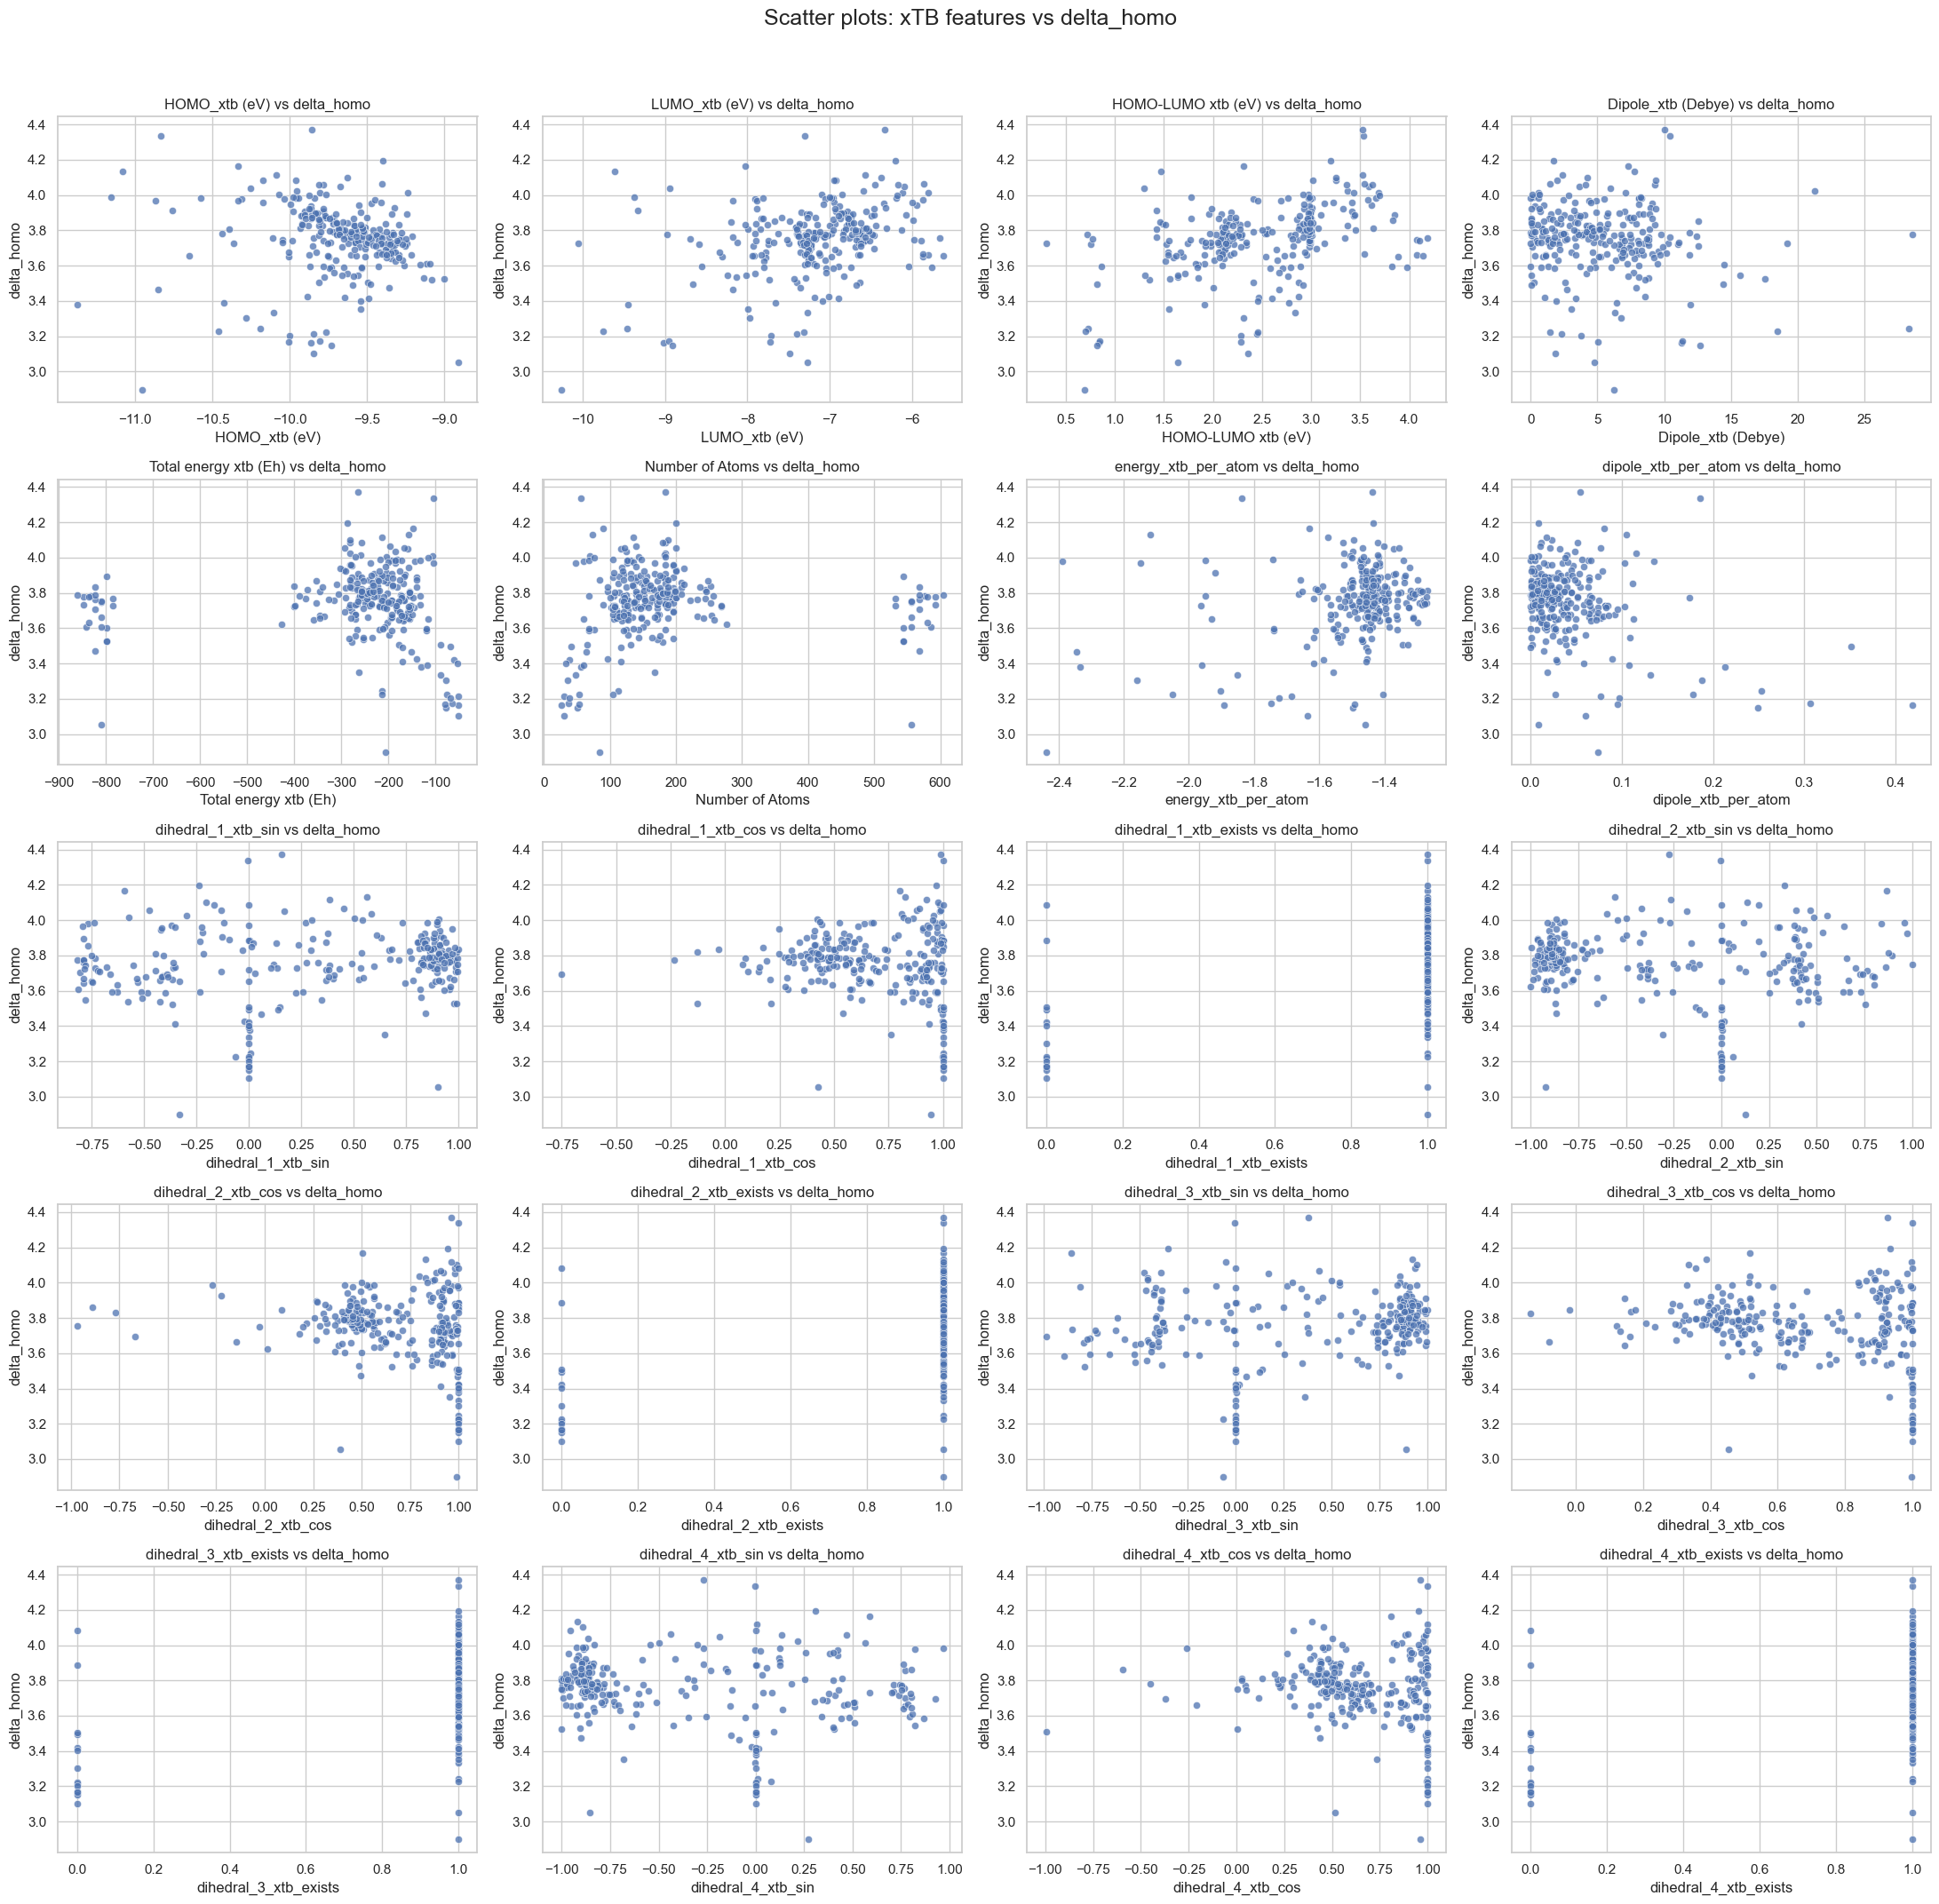

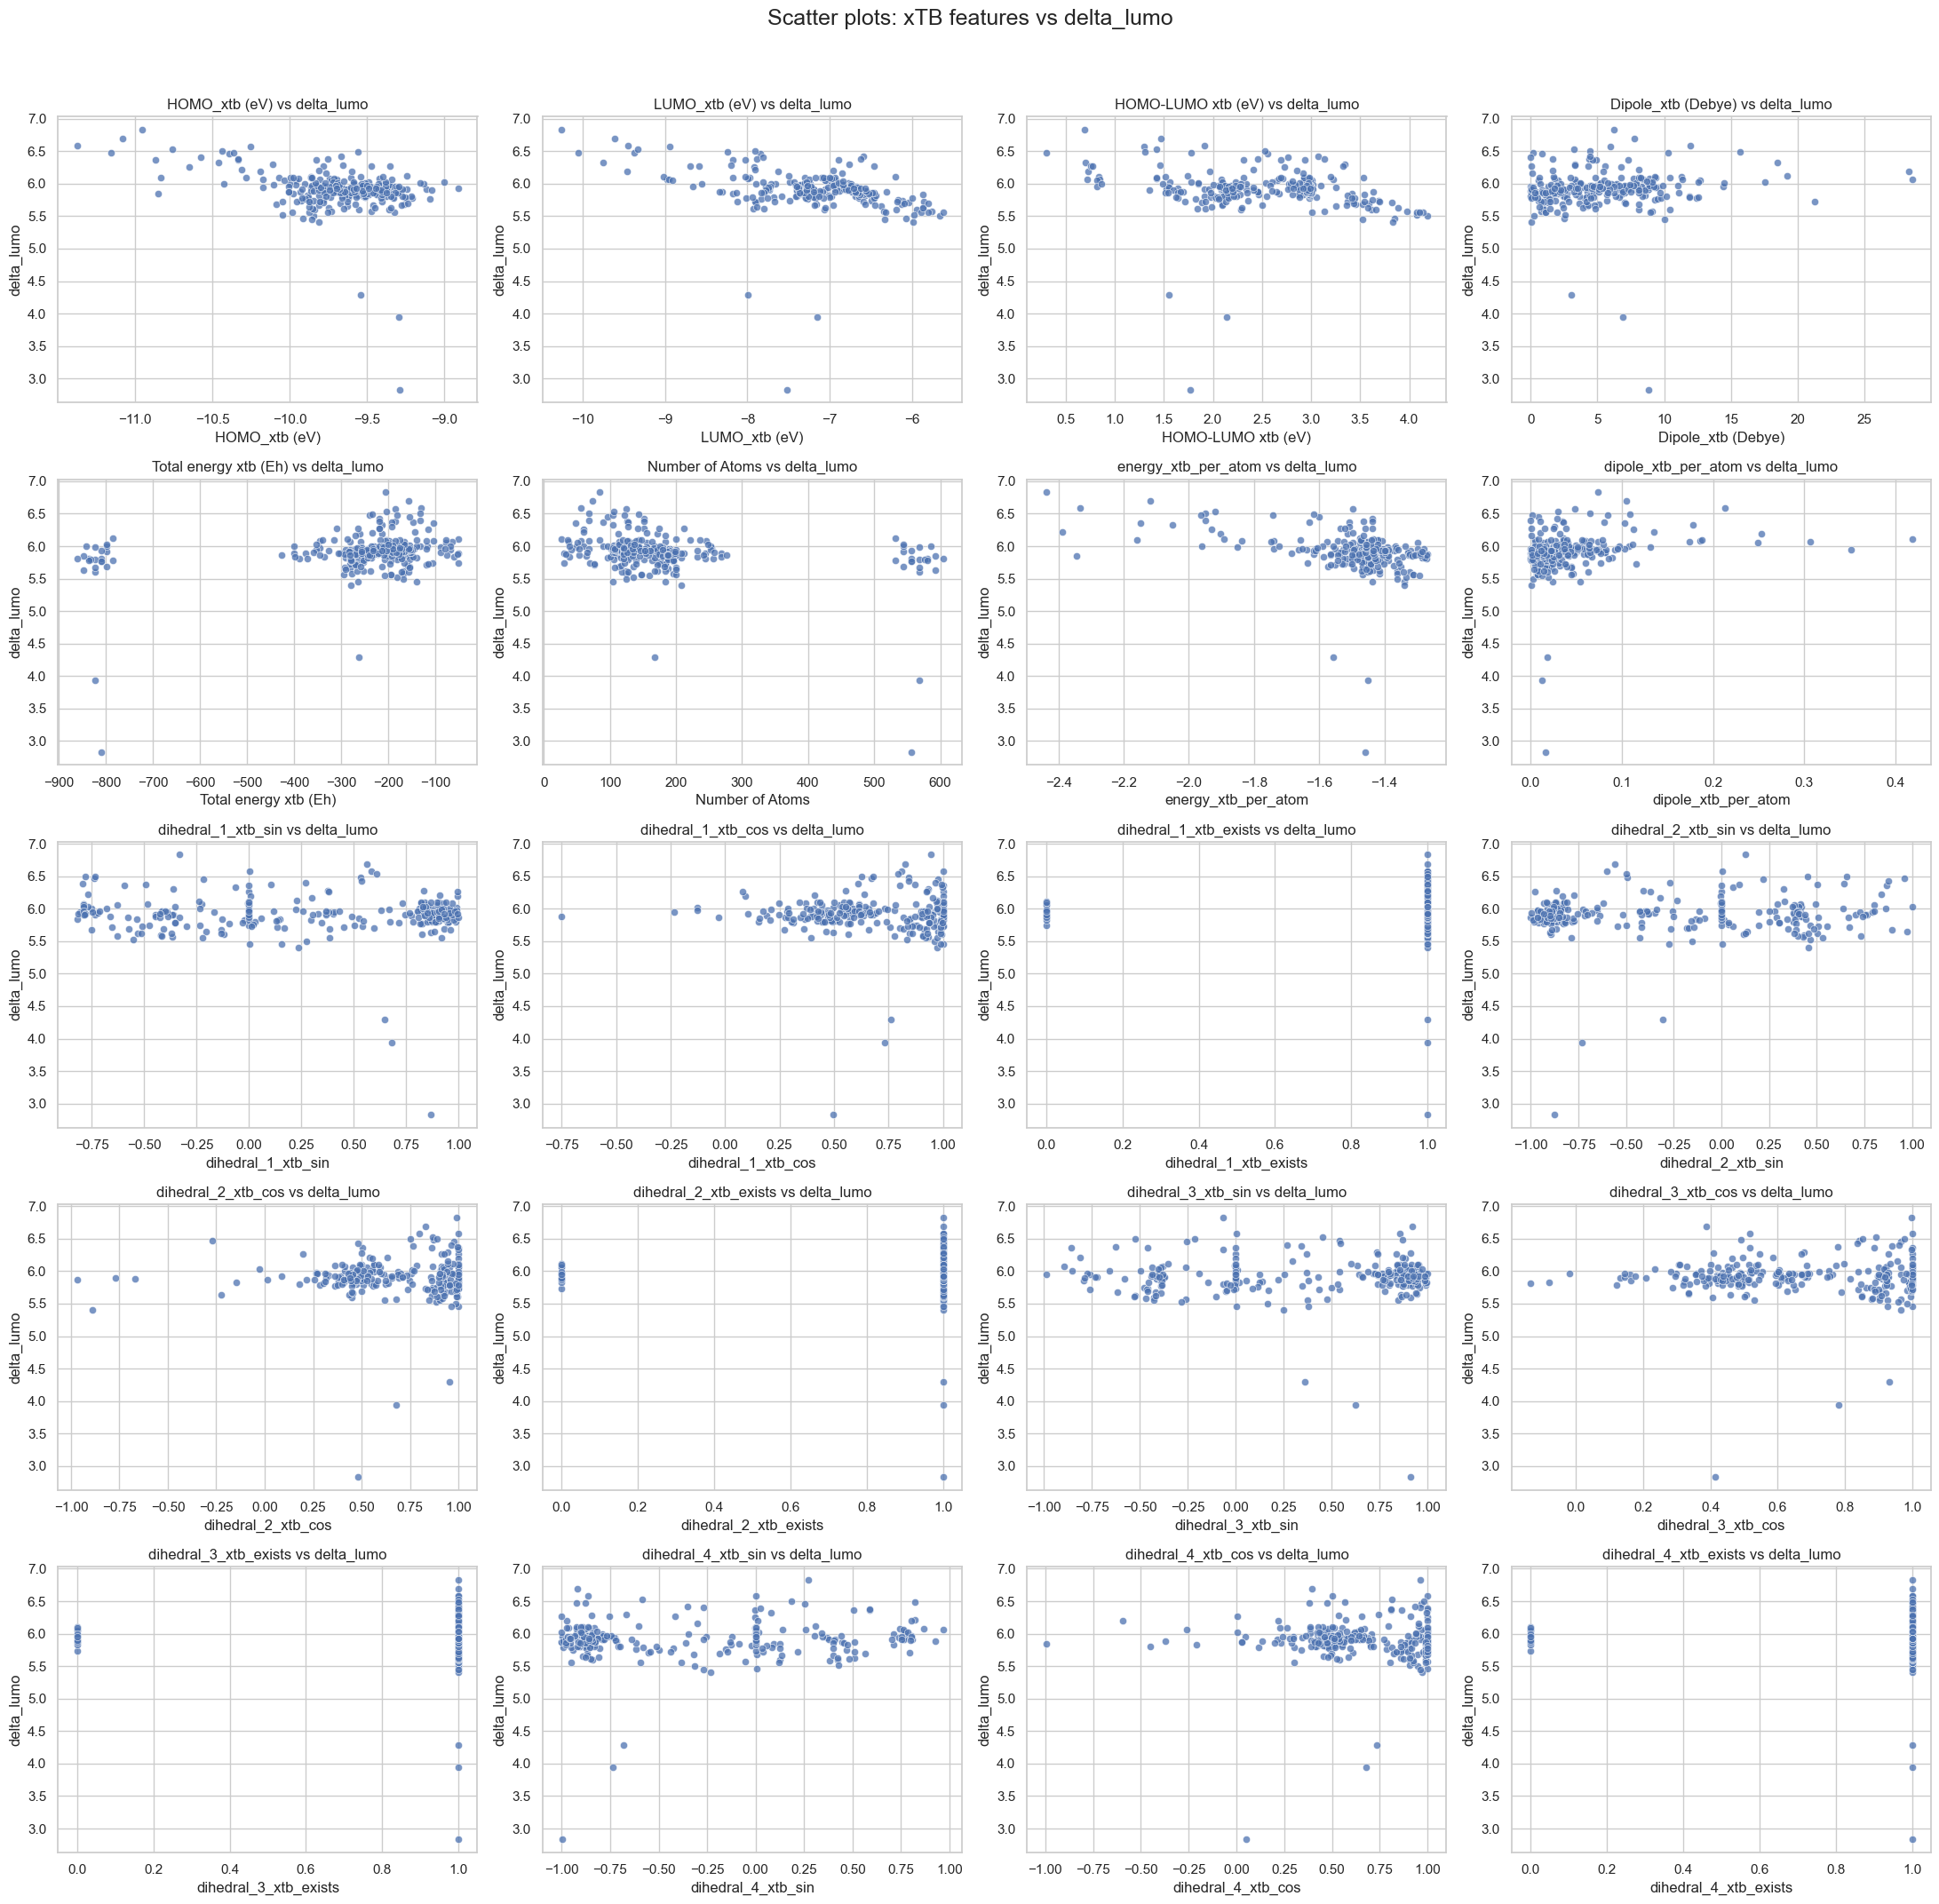

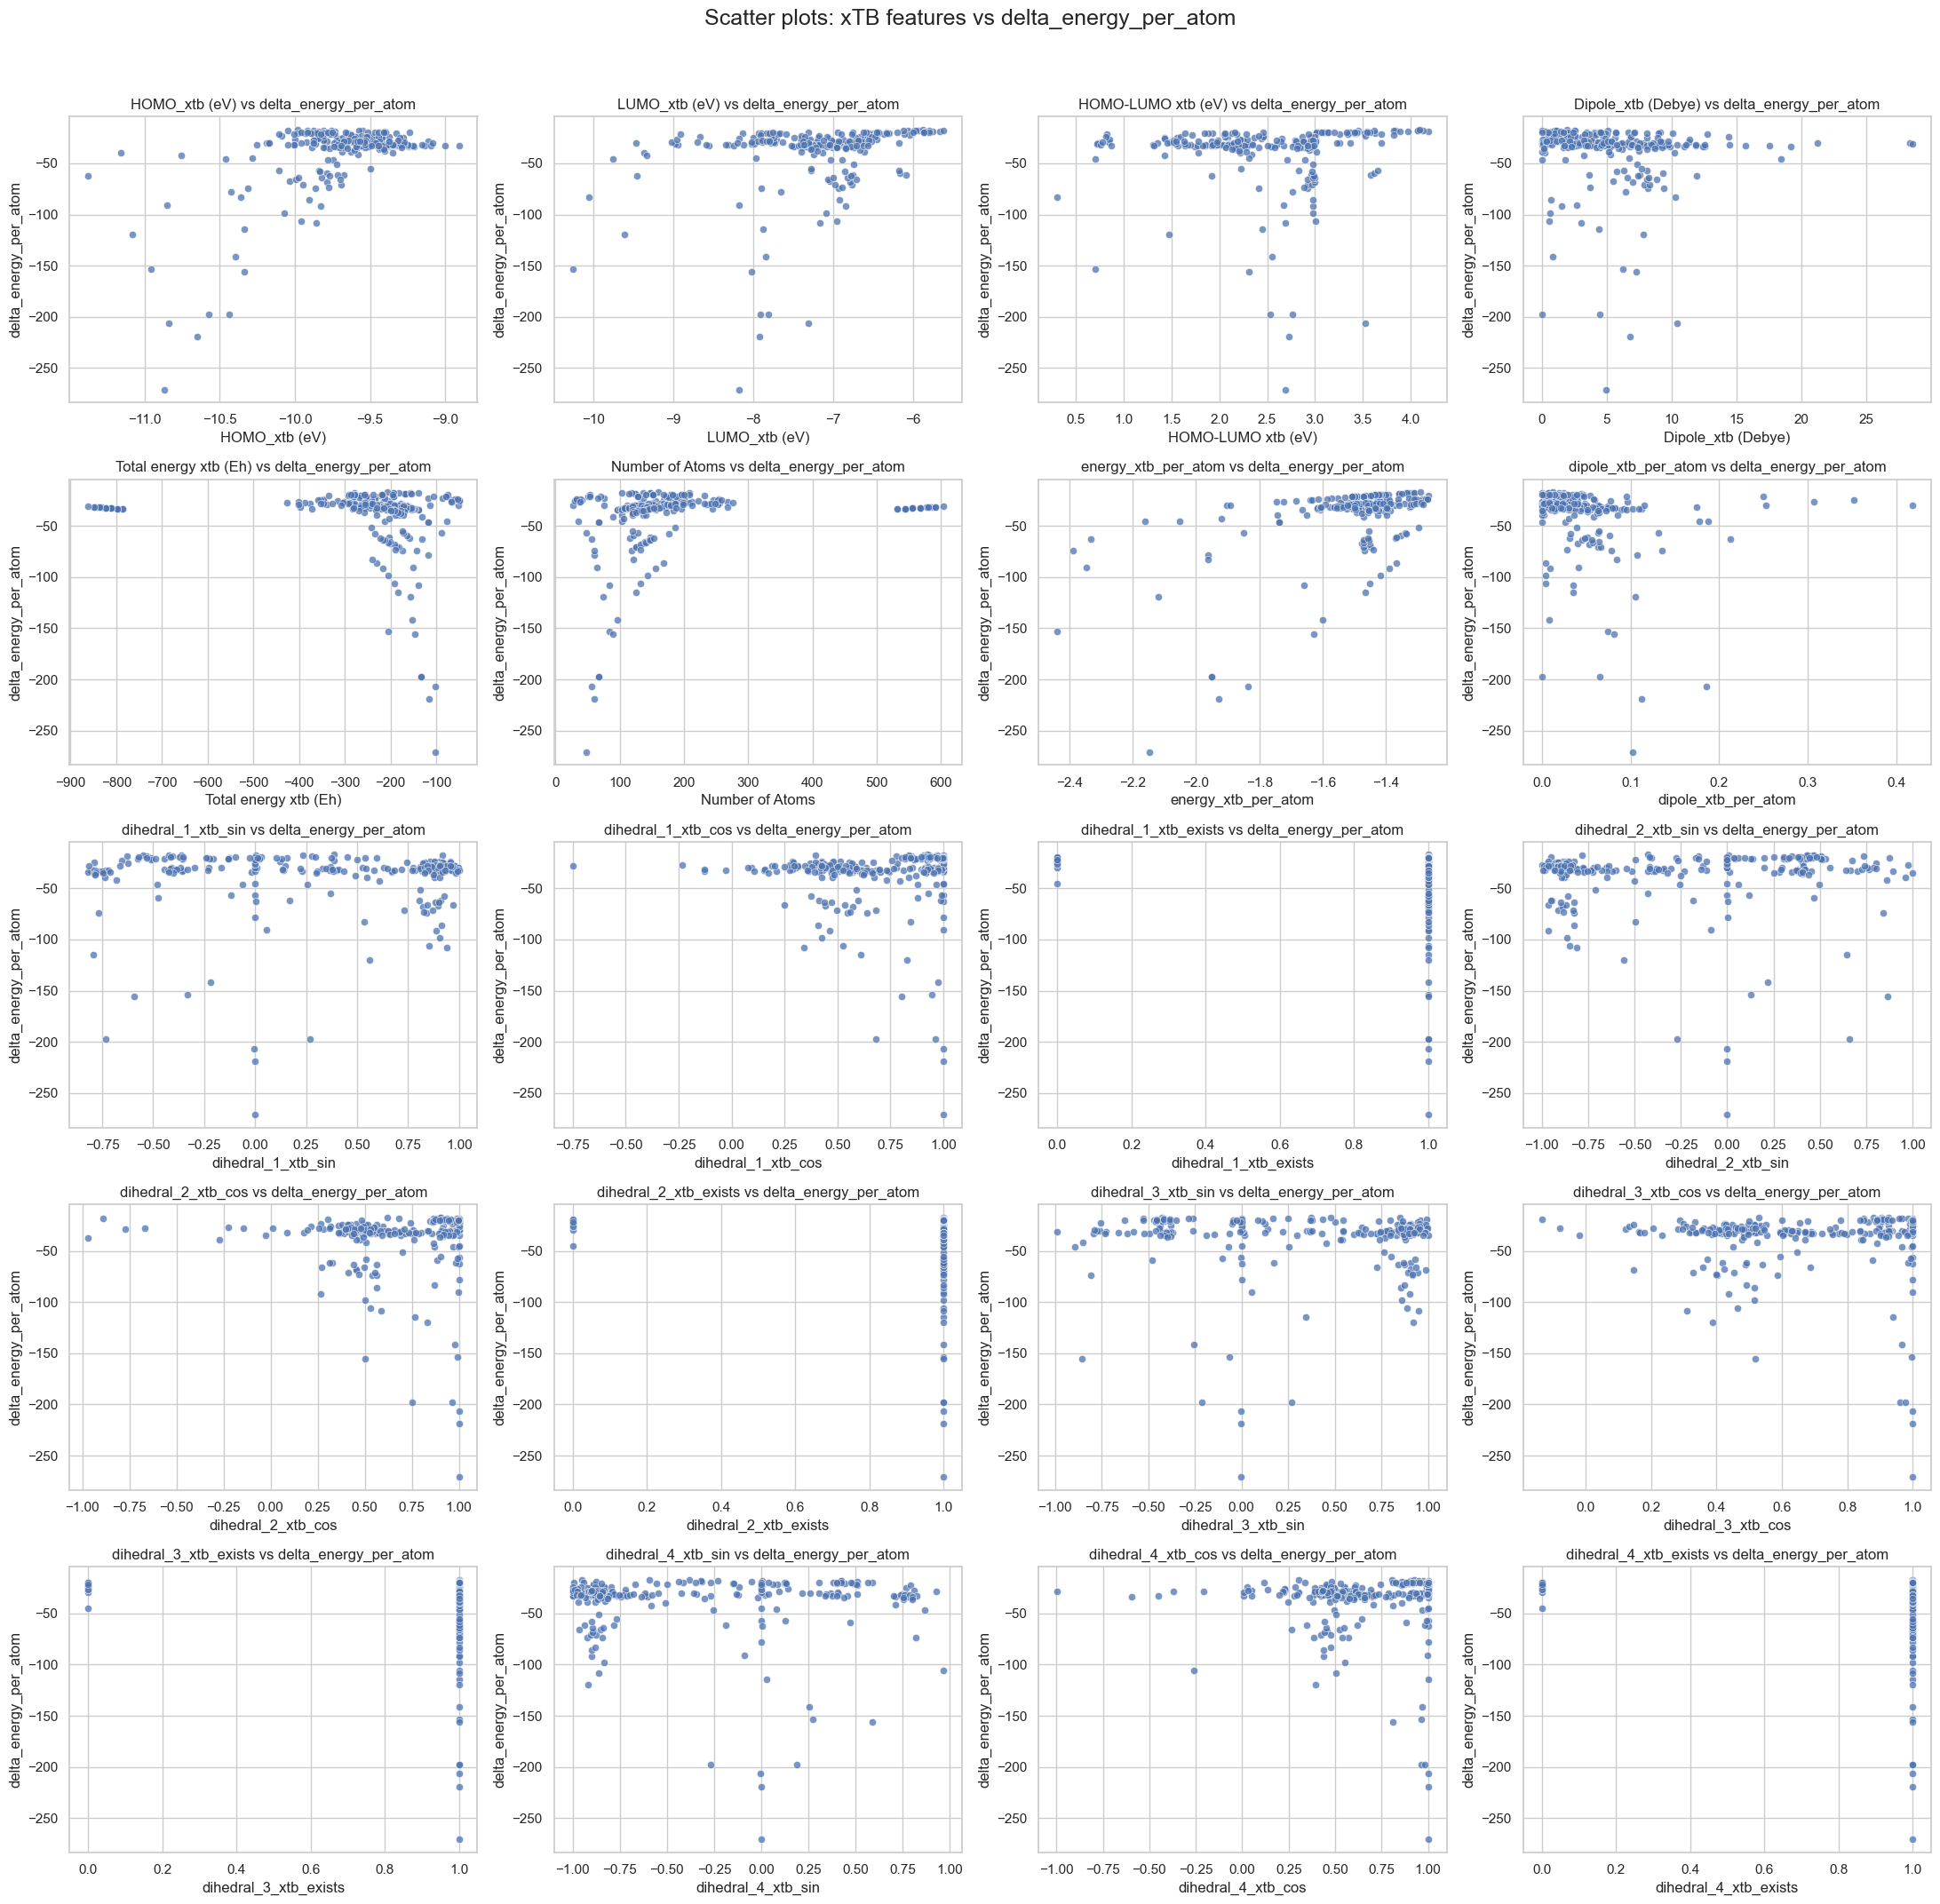

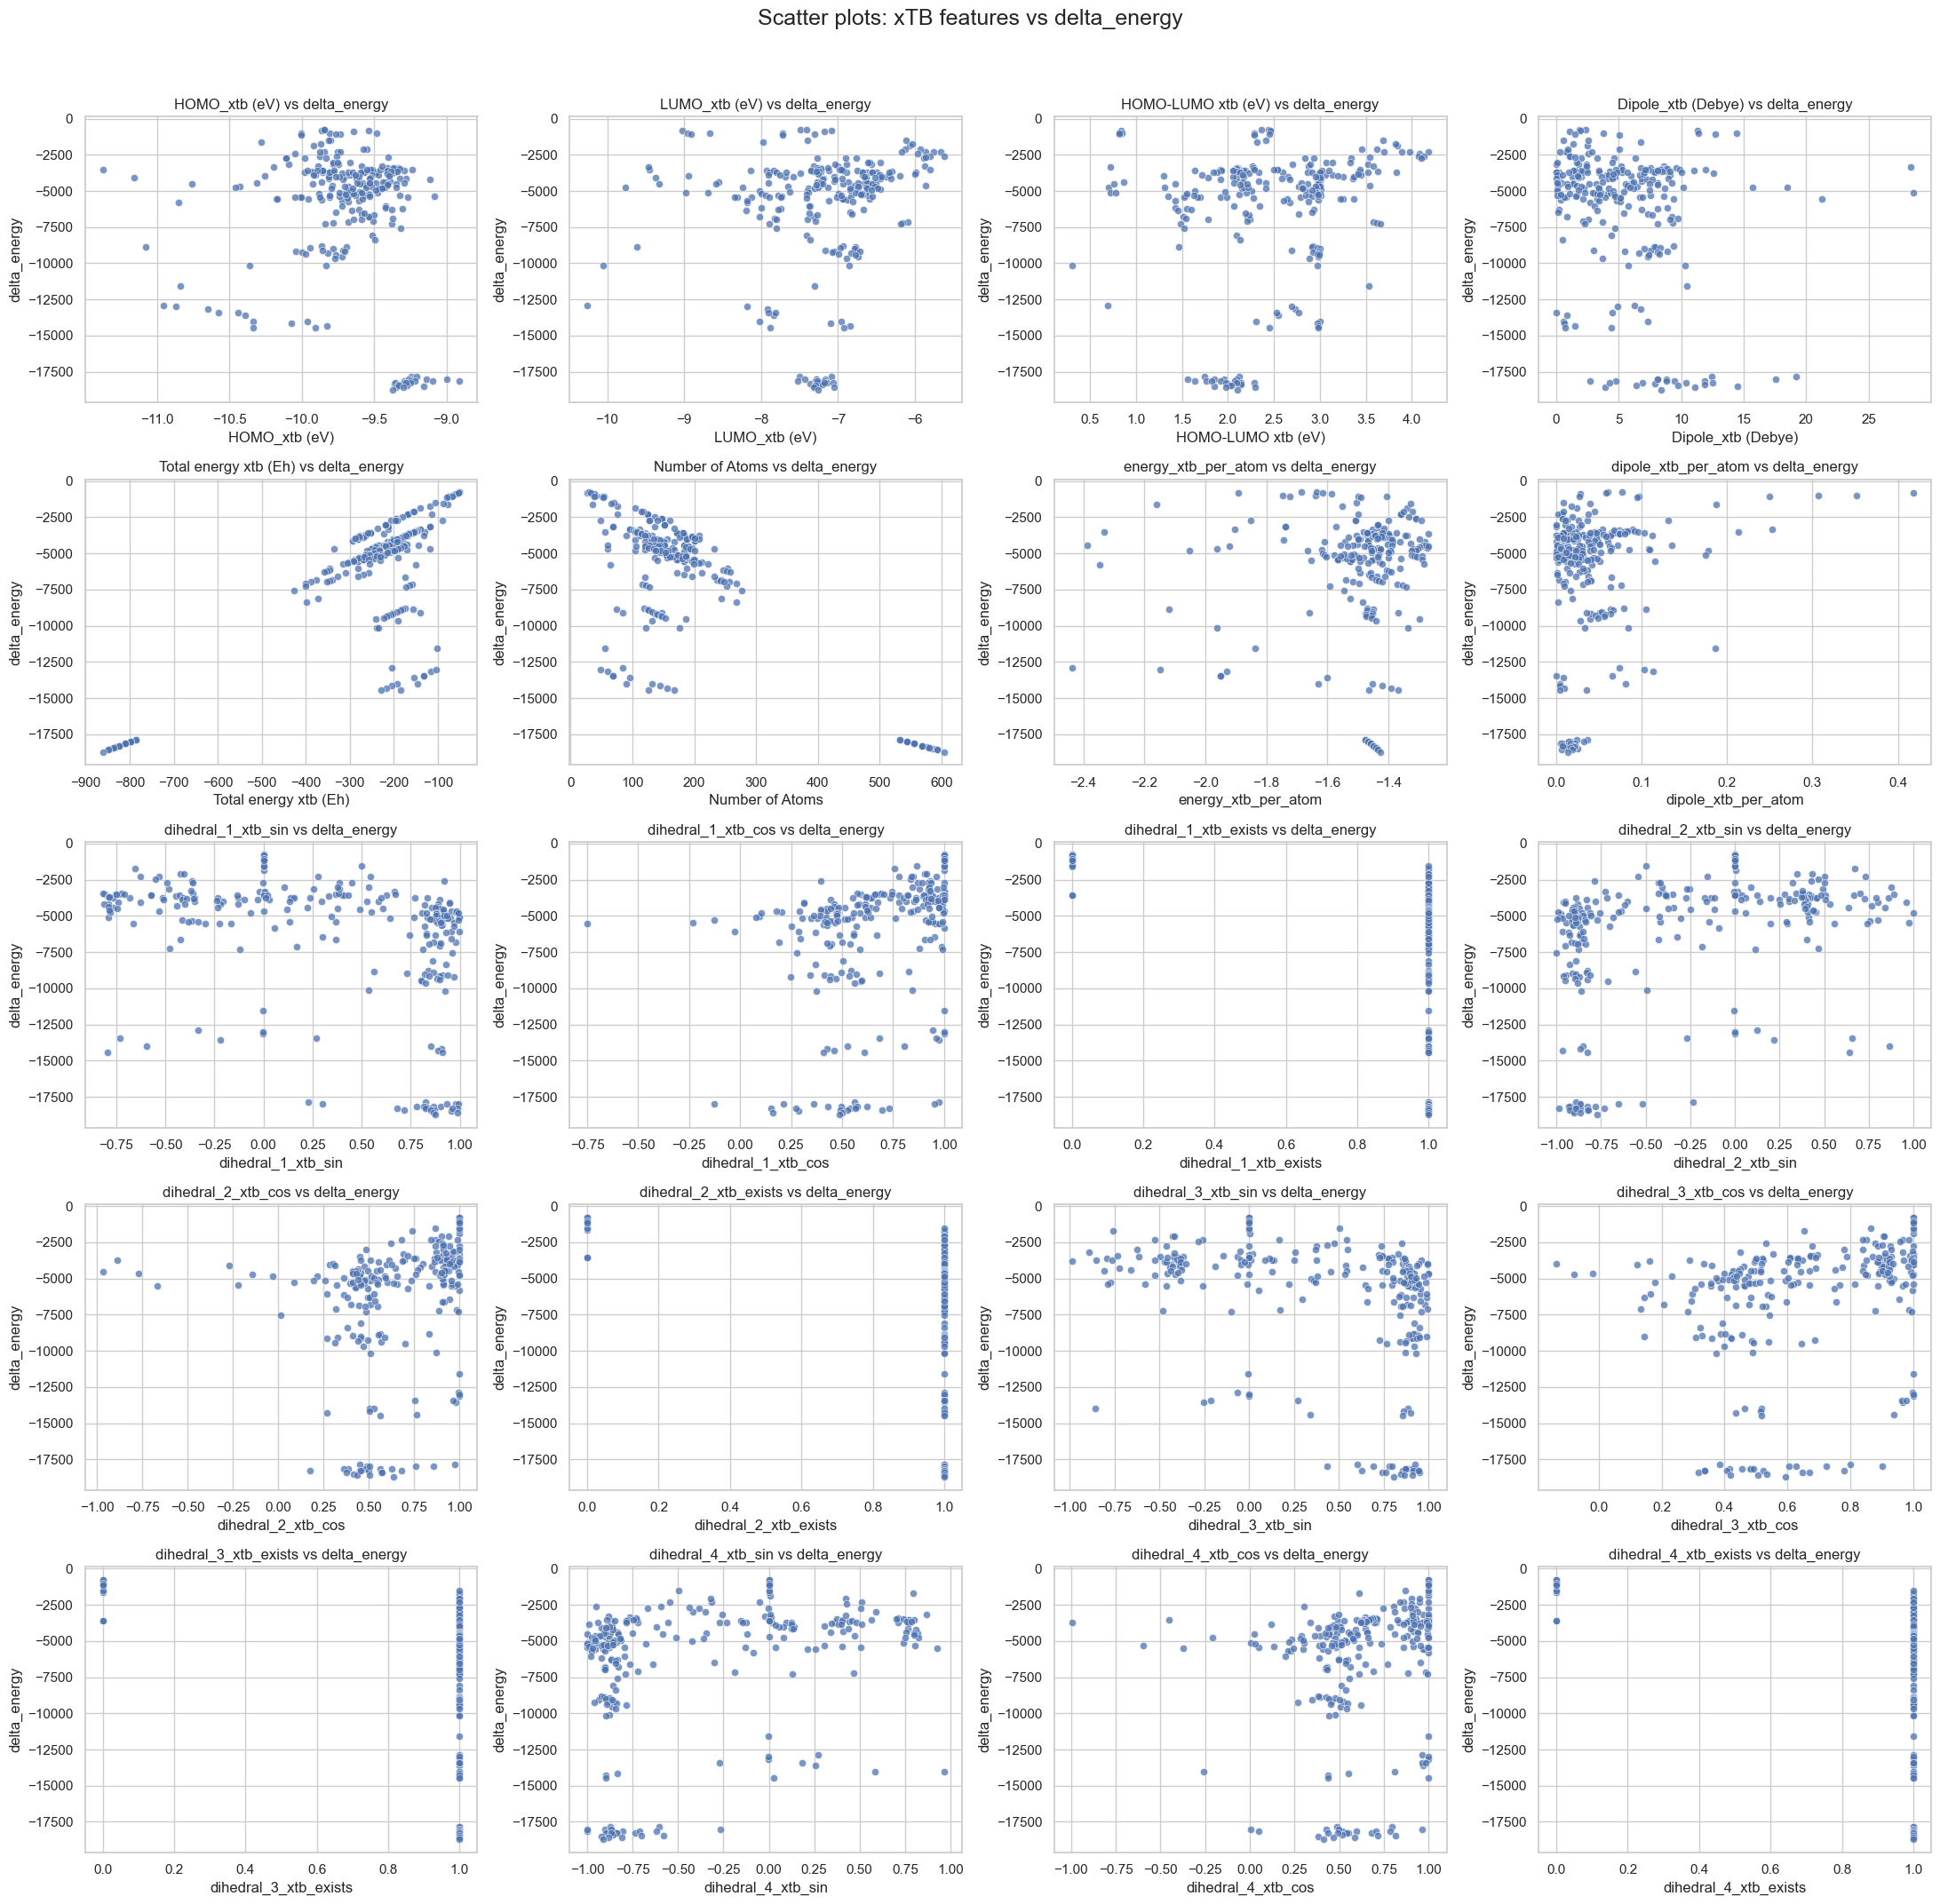

In [142]:

xtb_features_eda = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

targets_eda = ["delta_homo", "delta_lumo", "delta_energy_per_atom", "delta_energy"]

for target in targets_eda:
    n_cols = 4
    n_rows = int(np.ceil(len(xtb_features_eda) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(xtb_features_eda):
        sns.scatterplot(data=data, x=feature, y=target, ax=axes[i], s=35, alpha=0.75)
        axes[i].set_title(f"{feature} vs {target}")

    for j in range(len(xtb_features_eda), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Scatter plots: xTB features vs {target}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()


## 2.4 Correlation matrix between xTB features and target deltas

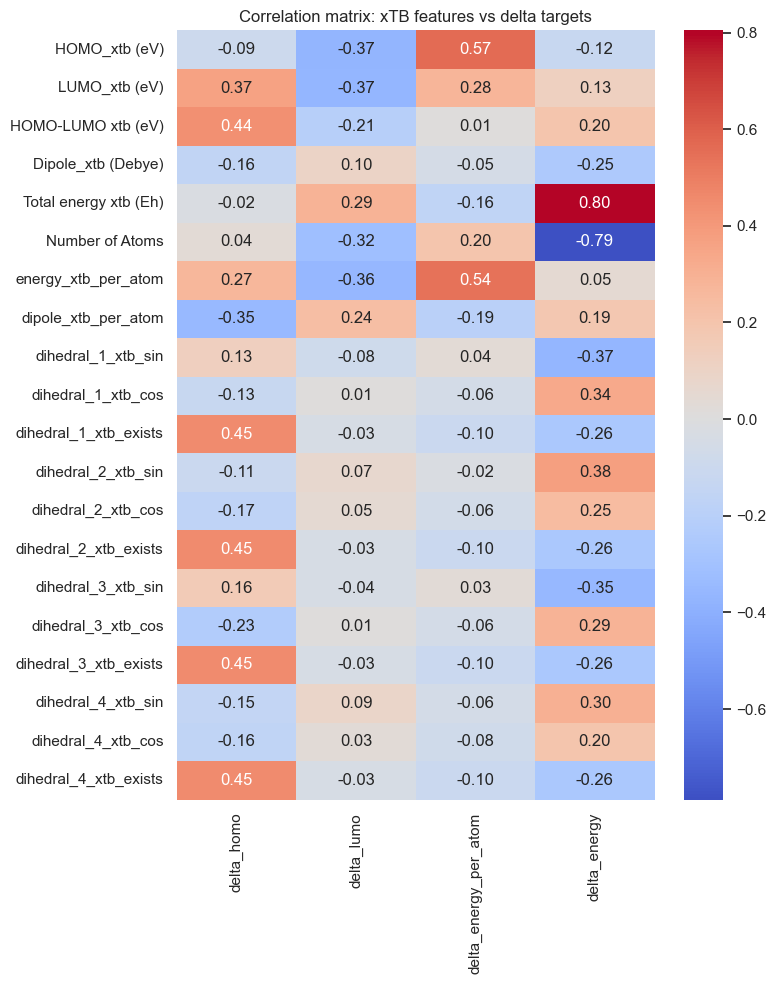

,delta_homo,delta_lumo,delta_energy_per_atom,delta_energy
HOMO_xtb (eV),-0.094330,-0.372198,0.567123,-0.124534
LUMO_xtb (eV),0.367857,-0.370530,0.280239,0.125669
HOMO-LUMO xtb (eV),0.436775,-0.205306,0.011836,0.195579
Dipole_xtb (Debye),-0.155025,0.100912,-0.051884,-0.248498
Total energy xtb (Eh),-0.016731,0.291253,-0.163535,0.804385
Number of Atoms,0.035864,-0.317971,0.200602,-0.787190
energy_xtb_per_atom,0.271652,-0.362316,0.540110,0.050723
dipole_xtb_per_atom,-0.351182,0.237538,-0.192674,0.188747
dihedral_1_xtb_sin,0.130179,-0.082596,0.038025,-0.365960
dihedral_1_xtb_cos,-0.126512,0.010036,-0.059642,0.336305


In [143]:

correlation_matrix = data[xtb_features_eda + targets_eda].corr().loc[xtb_features_eda, targets_eda]
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix: xTB features vs delta targets")
plt.tight_layout()
plt.show()

correlation_matrix


## 2.5 Ranked correlations

In [144]:

average_correlations = correlation_matrix.abs().mean(axis=1).sort_values(ascending=False)
max_correlations = correlation_matrix.abs().max(axis=1).sort_values(ascending=False)

print("Average absolute correlation")
display(average_correlations.to_frame("avg_abs_corr"))

print("Maximum absolute correlation")
display(max_correlations.to_frame("max_abs_corr"))


Average absolute correlation


,avg_abs_corr
Number of Atoms,0.335407
Total energy xtb (Eh),0.318976
energy_xtb_per_atom,0.306200
HOMO_xtb (eV),0.289546
LUMO_xtb (eV),0.286074
dipole_xtb_per_atom,0.242535
dihedral_3_xtb_exists,0.213465
dihedral_2_xtb_exists,0.213465
dihedral_1_xtb_exists,0.213465
dihedral_4_xtb_exists,0.213465


Maximum absolute correlation


,max_abs_corr
Total energy xtb (Eh),0.804385
Number of Atoms,0.787190
HOMO_xtb (eV),0.567123
energy_xtb_per_atom,0.540110
dihedral_3_xtb_exists,0.451601
dihedral_2_xtb_exists,0.451601
dihedral_1_xtb_exists,0.451601
dihedral_4_xtb_exists,0.451601
HOMO-LUMO xtb (eV),0.436775
dihedral_2_xtb_sin,0.381045


## 2.6 Distributions

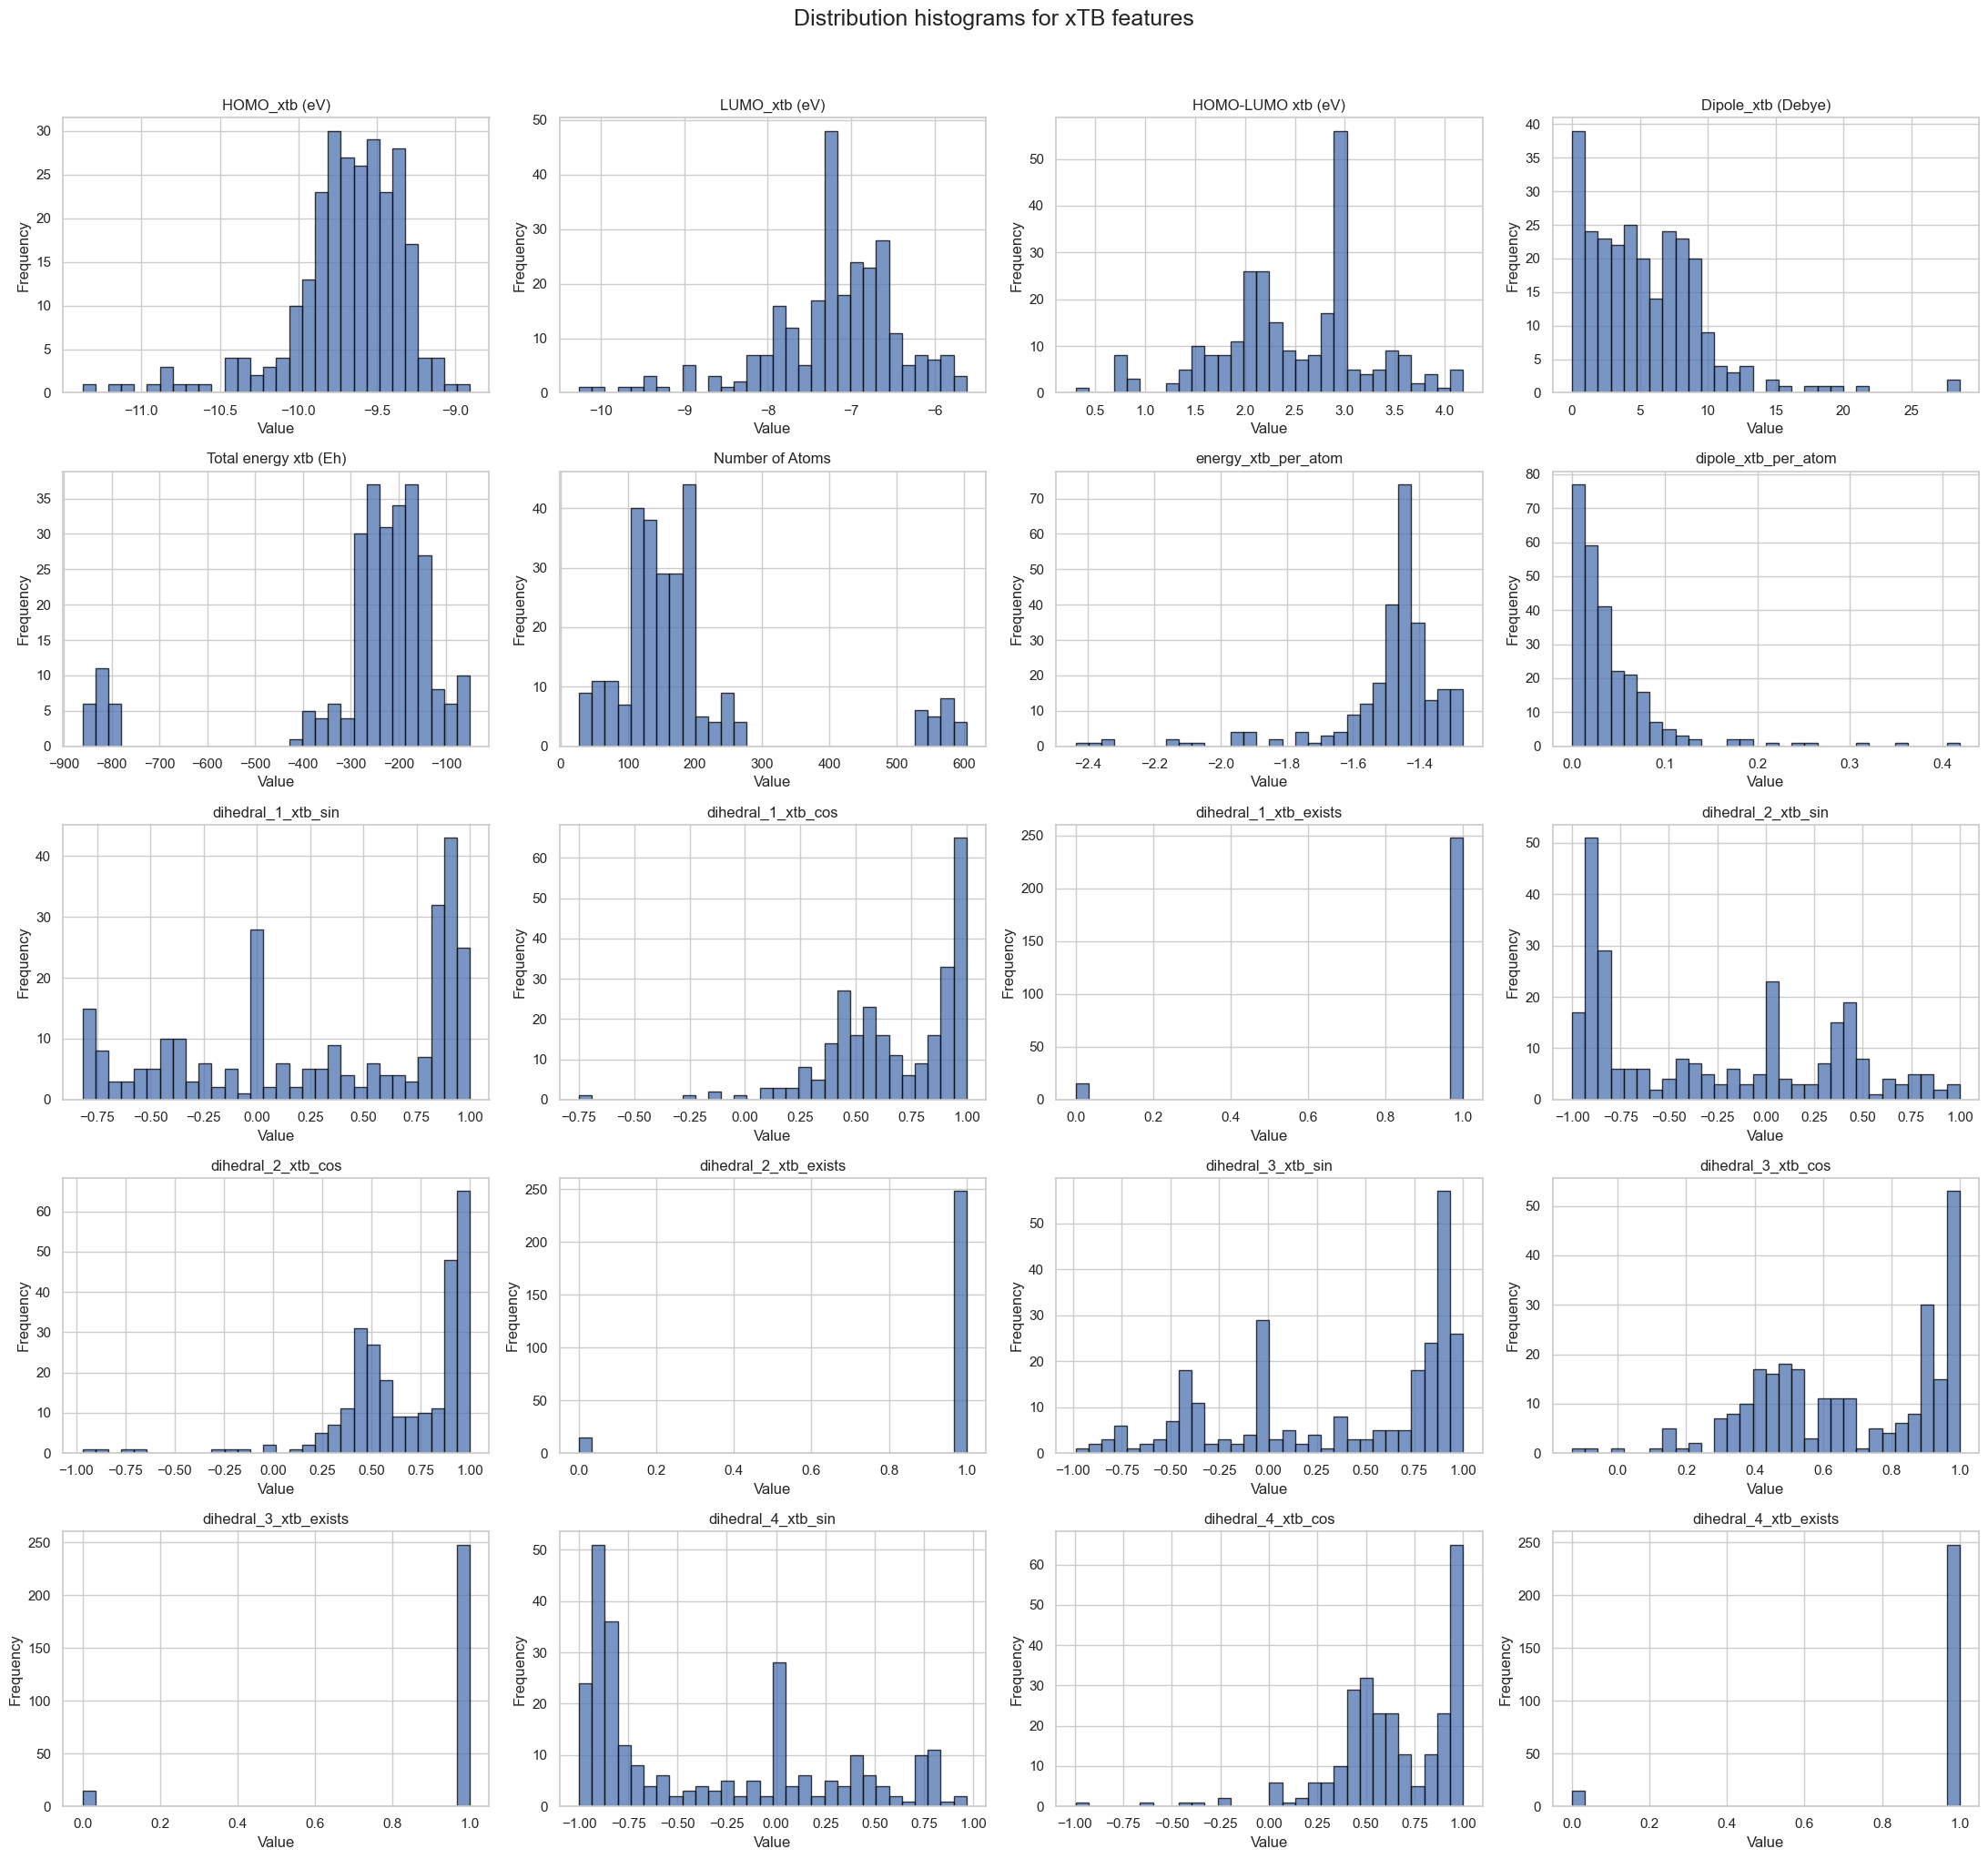

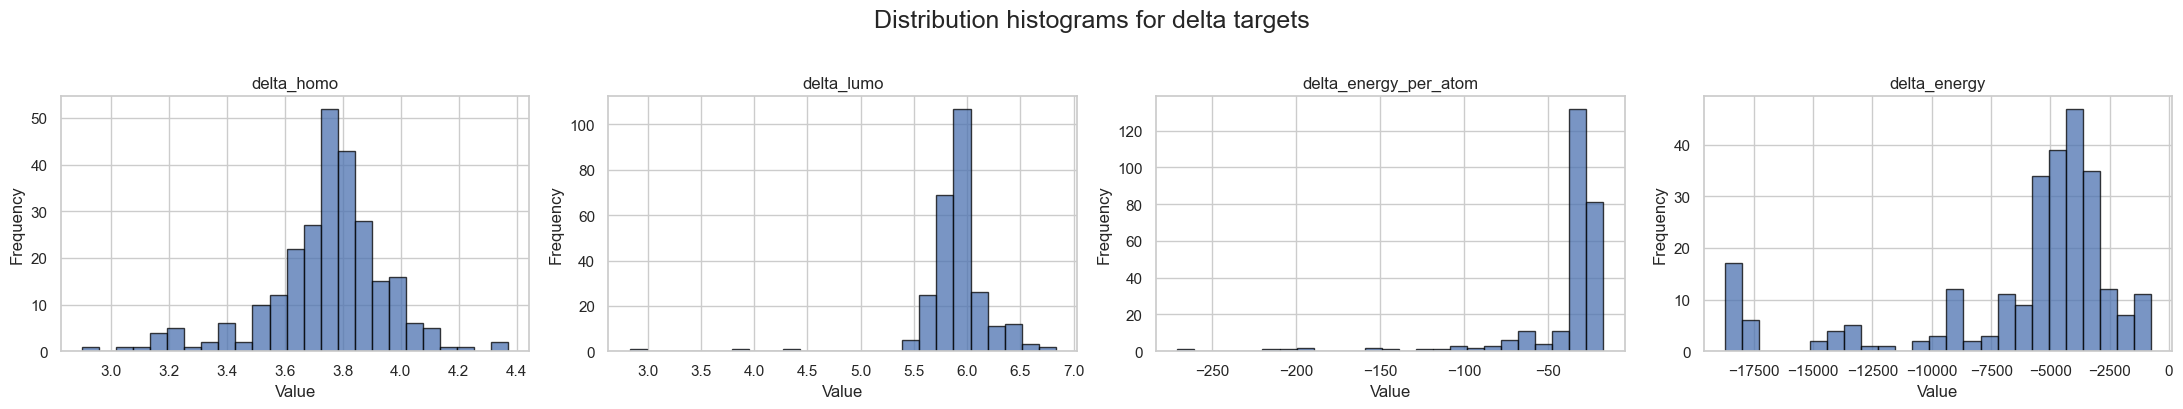

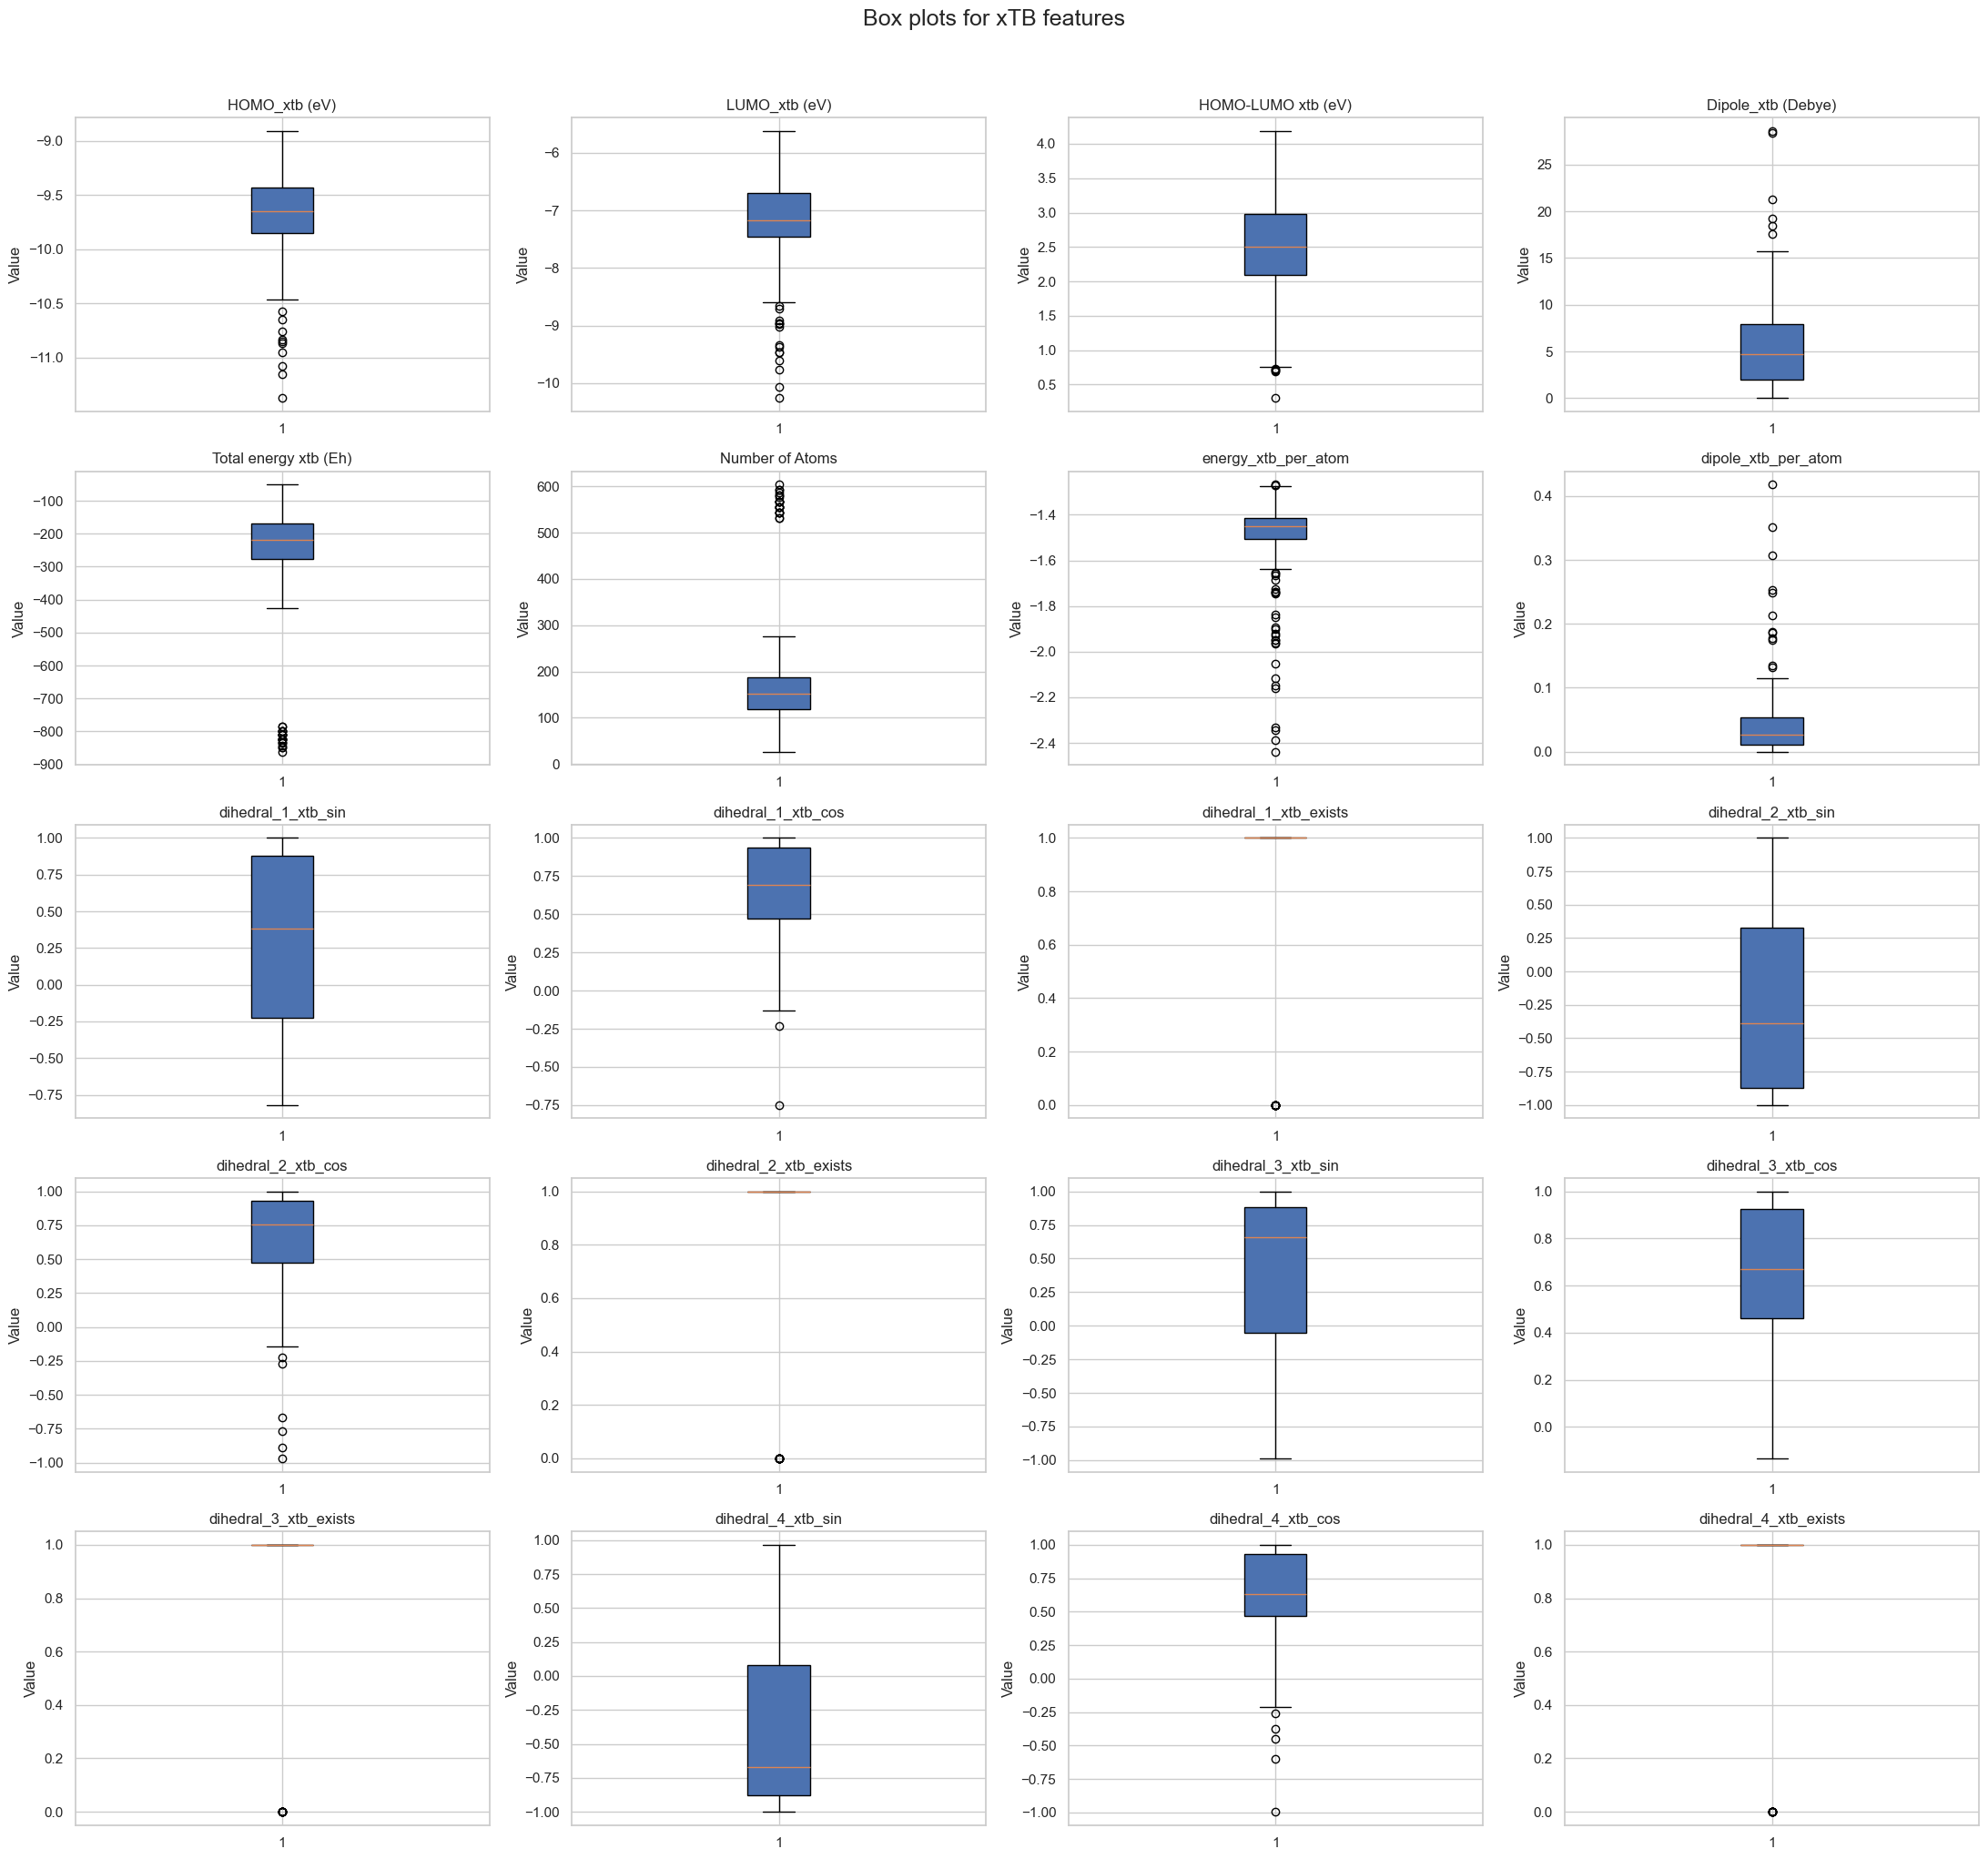

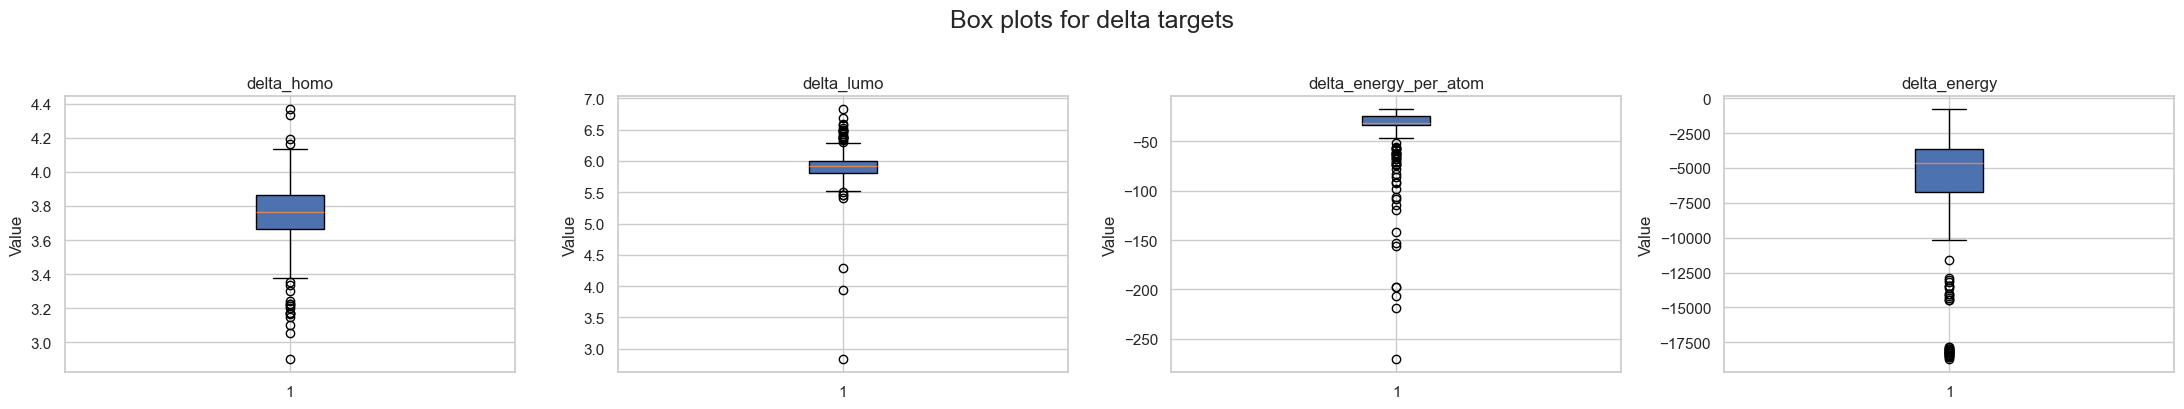

In [145]:

def plot_histograms(features, title, bins=30):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].hist(data[feature].dropna(), bins=bins, edgecolor="black", alpha=0.75)
        axes[i].set_title(feature)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_boxplots(features, title):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].boxplot(data[feature].dropna(), vert=True, patch_artist=True)
        axes[i].set_title(feature)
        axes[i].set_ylabel("Value")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_histograms(xtb_features_eda, "Distribution histograms for xTB features")
plot_histograms(targets_eda, "Distribution histograms for delta targets", bins=25)

plot_boxplots(xtb_features_eda, "Box plots for xTB features")
plot_boxplots(targets_eda, "Box plots for delta targets")


## 2.7 P-values for Pearson correlations

In [146]:

p_values = pd.DataFrame(index=xtb_features_eda, columns=targets_eda)

for xtb in xtb_features_eda:
    for target in targets_eda:
        _, p_value = pearsonr(data[xtb], data[target])
        p_values.loc[xtb, target] = p_value

p_values


,delta_homo,delta_lumo,delta_energy_per_atom,delta_energy
HOMO_xtb (eV),0.127038,0.0,0.0,0.043607
LUMO_xtb (eV),0.0,0.0,0.000004,0.041713
HOMO-LUMO xtb (eV),0.0,0.00081,0.848498,0.001435
Dipole_xtb (Debye),0.011825,0.102493,0.402045,0.000046
Total energy xtb (Eh),0.787114,0.000002,0.007875,0.0
Number of Atoms,0.562565,0.0,0.001072,0.0
energy_xtb_per_atom,0.000008,0.0,0.0,0.412676
dipole_xtb_per_atom,0.0,0.0001,0.001694,0.002112
dihedral_1_xtb_sin,0.034852,0.181749,0.539248,0.0
dihedral_1_xtb_cos,0.040349,0.871313,0.335305,0.0


# 3. Frozen 80/20 split and evaluation setup

## 3.1 Define feature and target sets

In [147]:
features_common = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "abs_homo_xtb",
    "abs_lumo_xtb",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

target_homo = "delta_homo"
target_lumo = "delta_lumo"

energy_target_candidates = [
    "delta_energy_per_atom",
    "delta_energy",
    "Final Energy (Eh)",
]
target_energy_default = "delta_energy_per_atom"

metadata_cols = [c for c in ["Folder", "File", "SMILES"] if c in data.columns]

true_target_cols = [
    "HOMO_orca (eV)",
    "LUMO_orca (eV)",
    "Final Energy (Eh)",
]

dataset_cols = list(dict.fromkeys(
    metadata_cols
    + features_common
    + true_target_cols
    + [target_homo, target_lumo]
    + energy_target_candidates
))

dataset = data[dataset_cols].dropna().copy()

dataset["row_index"] = dataset.index

if {"Folder", "File"}.issubset(dataset.columns):
    dataset["sample_id"] = dataset["Folder"].astype(str) + "/" + dataset["File"].astype(str)
else:
    dataset["sample_id"] = dataset.index.astype(str)

if "Folder" in dataset.columns:
    dataset["group_id"] = dataset["Folder"].astype(str)
else:
    dataset["group_id"] = dataset["sample_id"].astype(str)

metadata_export_cols = [
    c for c in ["row_index", "sample_id", "group_id", "Folder", "File", "SMILES"] if c in dataset.columns
]

X = dataset[features_common].copy()
y_homo = dataset[target_homo].copy()
y_lumo = dataset[target_lumo].copy()
y_energy = dataset[target_energy_default].copy()
groups = dataset["group_id"].copy()

print("X shape:", X.shape)
print("y_homo shape:", y_homo.shape)
print("y_lumo shape:", y_lumo.shape)
print("y_energy shape:", y_energy.shape)
print("Available energy targets:", energy_target_candidates)
print("Number of structural groups:", dataset["group_id"].nunique())

display(dataset[metadata_export_cols].head())


X shape: (263, 22)
y_homo shape: (263,)
y_lumo shape: (263,)
y_energy shape: (263,)
Available energy targets: ['delta_energy_per_atom', 'delta_energy', 'Final Energy (Eh)']
Number of structural groups: 22


,row_index,sample_id,group_id,Folder,File,SMILES
0,0,Group 1/1.log,Group 1,Group 1,1.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...
1,1,Group 1/2.log,Group 1,Group 1,2.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...
2,2,Group 1/3.log,Group 1,Group 1,3.log,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...
3,3,Group 1/4.log,Group 1,Group 1,4.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...
4,4,Group 1/5.log,Group 1,Group 1,5.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...


## 3.2 Frozen within-group 80/20 hold-out split

In [148]:

HOLDOUT_SPLIT_TYPE = "frozen_within_group_holdout"

split_path = os.path.join(OUTPUT_DIR, "frozen_within_group_holdout.json")
split_artifacts_path = os.path.join(OUTPUT_DIR, "frozen_within_group_split_artifacts.csv")
split_group_summary_path = os.path.join(OUTPUT_DIR, "frozen_within_group_split_group_summary.csv")

stable_group_column = "Folder" if "Folder" in dataset.columns else "group_id"
groups = dataset[stable_group_column].astype(str)

HOLDOUT_TEST_SIZE = 0.2

def make_within_group_holdout_indices(group_series, test_size, random_state):
    group_series = pd.Series(group_series).reset_index(drop=True).astype(str)
    rng = np.random.RandomState(random_state)

    train_idx_all = []
    test_idx_all = []

    for group_name in sorted(group_series.unique()):
        group_idx = np.where(group_series.to_numpy() == group_name)[0]
        group_idx = np.asarray(group_idx, dtype=int).copy()
        rng.shuffle(group_idx)

        n_group = len(group_idx)
        if n_group < 2:
            raise ValueError(
                f"Group '{group_name}' has only {n_group} sample(s). "
                "Within-group holdout requires at least 2 samples per group."
            )

        n_test = int(round(n_group * test_size))
        n_test = max(1, min(n_group - 1, n_test))

        test_idx = np.sort(group_idx[:n_test])
        train_idx = np.sort(group_idx[n_test:])

        if len(train_idx) == 0 or len(test_idx) == 0:
            raise RuntimeError(
                f"Failed to split group '{group_name}' into non-empty train/test parts."
            )

        train_idx_all.extend(train_idx.tolist())
        test_idx_all.extend(test_idx.tolist())

    train_idx_all = sorted(train_idx_all)
    test_idx_all = sorted(test_idx_all)

    overlap = sorted(set(train_idx_all) & set(test_idx_all))
    if len(overlap) > 0:
        raise RuntimeError(f"Index leakage detected in within-group holdout: {overlap}")

    return train_idx_all, test_idx_all

recreate_split = False
split_info = None

if os.path.exists(split_path):
    with open(split_path, "r", encoding="utf-8") as f:
        split_info = json.load(f)

    print("Loaded frozen WITHIN-GROUP split from:", split_path)

    saved_train_indices = split_info.get("train_indices")
    saved_test_indices = split_info.get("test_indices")

    if saved_train_indices is None or saved_test_indices is None:
        recreate_split = True
    else:
        saved_train_indices = sorted([int(x) for x in saved_train_indices])
        saved_test_indices = sorted([int(x) for x in saved_test_indices])

        current_index_set = set(dataset.index.tolist())
        saved_union = set(saved_train_indices) | set(saved_test_indices)
        saved_overlap = sorted(set(saved_train_indices) & set(saved_test_indices))

        if len(saved_overlap) > 0:
            recreate_split = True
        elif saved_union != current_index_set:
            recreate_split = True
        else:
            train_indices = saved_train_indices
            test_indices = saved_test_indices
else:
    recreate_split = True

if recreate_split:
    train_pos, test_pos = make_within_group_holdout_indices(
        group_series=groups,
        test_size=HOLDOUT_TEST_SIZE,
        random_state=RANDOM_STATE
    )

    train_indices = X.index[train_pos].tolist()
    test_indices = X.index[test_pos].tolist()

    split_info = {
        "split_type": HOLDOUT_SPLIT_TYPE,
        "group_column": stable_group_column,
        "random_state": RANDOM_STATE,
        "test_size": HOLDOUT_TEST_SIZE,
        "train_indices": train_indices,
        "test_indices": test_indices,
        "n_train_samples": len(train_indices),
        "n_test_samples": len(test_indices),
    }

    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(split_info, f, ensure_ascii=False, indent=4)

    print("Created and saved frozen WITHIN-GROUP split:", split_path)

train_indices = sorted([int(x) for x in train_indices])
test_indices = sorted([int(x) for x in test_indices])

index_overlap = sorted(set(train_indices) & set(test_indices))
if len(index_overlap) > 0:
    raise RuntimeError(f"Index leakage detected in frozen within-group split: {index_overlap}")

if sorted(train_indices + test_indices) != sorted(dataset.index.tolist()):
    raise RuntimeError("Frozen within-group split does not cover the full dataset exactly once.")

holdout_split_artifacts_df = dataset.loc[
    train_indices + test_indices,
    metadata_export_cols
].copy()

holdout_split_artifacts_df["subset"] = np.where(
    holdout_split_artifacts_df.index.isin(train_indices),
    "train",
    "test"
)

holdout_group_summary_df = (
    holdout_split_artifacts_df
    .groupby(["group_id", "subset"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

holdout_group_summary_df["total"] = holdout_group_summary_df["train"] + holdout_group_summary_df["test"]
holdout_group_summary_df["train_fraction"] = holdout_group_summary_df["train"] / holdout_group_summary_df["total"]
holdout_group_summary_df["test_fraction"] = holdout_group_summary_df["test"] / holdout_group_summary_df["total"]

holdout_split_artifacts_df.to_csv(split_artifacts_path, index=False)
holdout_group_summary_df.to_csv(split_group_summary_path, index=False)

print("Saved:", split_artifacts_path)
print("Saved:", split_group_summary_path)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()

y_homo_train = y_homo.loc[train_indices].copy()
y_homo_test = y_homo.loc[test_indices].copy()

y_lumo_train = y_lumo.loc[train_indices].copy()
y_lumo_test = y_lumo.loc[test_indices].copy()

y_energy_train = y_energy.loc[train_indices].copy()
y_energy_test = y_energy.loc[test_indices].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(holdout_group_summary_df.sort_values("group_id").reset_index(drop=True))


Created and saved frozen WITHIN-GROUP split: ./output_within_group_holdout_pruned_v4\frozen_within_group_holdout.json
Saved: ./output_within_group_holdout_pruned_v4\frozen_within_group_split_artifacts.csv
Saved: ./output_within_group_holdout_pruned_v4\frozen_within_group_split_group_summary.csv
Train shape: (210, 22)
Test shape: (53, 22)


subset,group_id,test,train,total,train_fraction,test_fraction
0,Group 1,2,9,11,0.818182,0.181818
1,Group 10,3,10,13,0.769231,0.230769
2,Group 11,5,18,23,0.782609,0.217391
3,Group 12,2,8,10,0.800000,0.200000
4,Group 13,4,18,22,0.818182,0.181818
5,Group 14,3,14,17,0.823529,0.176471
6,Group 15,2,8,10,0.800000,0.200000
7,Group 16,2,8,10,0.800000,0.200000
8,Group 17,1,1,2,0.500000,0.500000
9,Group 18,1,3,4,0.750000,0.250000


## 3.3 Robust weighting for energy target

In [149]:
def mad(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))


def robust_sample_weights(y, c=2.5, min_weight=0.2):
    y = np.asarray(y, dtype=float)
    med = np.median(y)
    y_mad = mad(y)

    if y_mad < 1e-12:
        return np.ones_like(y, dtype=float)

    robust_z = 0.6745 * (y - med) / y_mad
    abs_z = np.abs(robust_z)

    weights = np.ones_like(abs_z, dtype=float)
    mask = abs_z > c
    weights[mask] = c / abs_z[mask]
    weights = np.clip(weights, min_weight, 1.0)

    return weights


def soft_sample_weights(y, c=3.5, min_weight=0.5):
    y = np.asarray(y, dtype=float)
    med = np.median(y)
    y_mad = mad(y)

    if y_mad < 1e-12:
        return np.ones_like(y, dtype=float)

    robust_z = 0.6745 * (y - med) / y_mad
    abs_z = np.abs(robust_z)

    weights = np.ones_like(abs_z, dtype=float)
    mask = abs_z > c
    weights[mask] = c / abs_z[mask]
    weights = np.clip(weights, min_weight, 1.0)

    return weights


def no_sample_weights(y):
    y = np.asarray(y, dtype=float)
    return np.ones_like(y, dtype=float)


weighting_schemes = {
    "robust": lambda y: robust_sample_weights(y, c=2.5, min_weight=0.2),
    "soft": lambda y: soft_sample_weights(y, c=3.5, min_weight=0.5),
    "none": lambda y: no_sample_weights(y),
}

energy_sample_weights_train = pd.DataFrame({
    "robust": weighting_schemes["robust"](y_energy_train),
    "soft": weighting_schemes["soft"](y_energy_train),
    "none": weighting_schemes["none"](y_energy_train),
}, index=y_energy_train.index)

print("Energy sample weights summary:")
display(energy_sample_weights_train.describe())

Energy sample weights summary:


,robust,soft,none
count,210.000000,210.000000,210.0
mean,0.911552,0.947217,1.0
std,0.223849,0.144633,0.0
min,0.200000,0.500000,1.0
25%,1.000000,1.000000,1.0
50%,1.000000,1.000000,1.0
75%,1.000000,1.000000,1.0
max,1.000000,1.000000,1.0


## 3.4 Weighting schemes for energy ablation

In [150]:
split_summary_df = pd.DataFrame({
    "subset": ["train", "test"],
    "n_samples": [len(X_train), len(X_test)],
    "n_groups": [
        dataset.loc[X_train.index, "group_id"].nunique(),
        dataset.loc[X_test.index, "group_id"].nunique(),
    ],
})

display(split_summary_df)


,subset,n_samples,n_groups
0,train,210,22
1,test,53,22


## 3.5 Helper variables for hold-out baseline

In [151]:
homo_xtb_test = X_test["HOMO_xtb (eV)"].values
lumo_xtb_test = X_test["LUMO_xtb (eV)"].values
energy_xtb_test = X_test["Total energy xtb (Eh)"].values

homo_true_test = data.loc[X_test.index, "HOMO_orca (eV)"].values
lumo_true_test = data.loc[X_test.index, "LUMO_orca (eV)"].values
energy_true_test = data.loc[X_test.index, "Final Energy (Eh)"].values

display(pd.DataFrame({
    "target": ["HOMO", "LUMO", "Final Energy"],
    "baseline_source": ["HOMO_xtb (eV)", "LUMO_xtb (eV)", "Total energy xtb (Eh)"],
    "n_test_samples": [len(X_test), len(X_test), len(X_test)],
}))

,target,baseline_source,n_test_samples
0,HOMO,HOMO_xtb (eV),53
1,LUMO,LUMO_xtb (eV),53
2,Final Energy,Total energy xtb (Eh),53


## 3.6 Helper metrics

In [152]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_pred - y_true)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MedAE": np.median(abs_err),
        "Q90_AE": np.quantile(abs_err, 0.90),
        "Q95_AE": np.quantile(abs_err, 0.95),
        "Max_AE": np.max(abs_err),
        "n_samples": len(y_true),
    }


def build_metrics_row(evaluation_type, split_type, model, target, unit, y_true, y_pred):
    row = {
        "evaluation_type": evaluation_type,
        "split_type": split_type,
        "model": model,
        "target": target,
        "unit": unit,
    }
    row.update(regression_metrics(y_true, y_pred))
    return row

## 3.7 Baseline hold-out metrics

In [153]:
baseline_holdout_rows = [
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="HOMO",
        unit="eV",
        y_true=homo_true_test,
        y_pred=homo_xtb_test,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="LUMO",
        unit="eV",
        y_true=lumo_true_test,
        y_pred=lumo_xtb_test,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model="xTB baseline",
        target="Final Energy",
        unit="Eh",
        y_true=energy_true_test,
        y_pred=energy_xtb_test,
    ),
]

baseline_holdout_metrics_df = pd.DataFrame(baseline_holdout_rows)
baseline_holdout_metrics_df

,evaluation_type,split_type,model,target,unit,MAE,RMSE,R2,MedAE,Q90_AE,Q95_AE,Max_AE,n_samples
0,holdout_test,frozen_within_group_holdout,xTB baseline,HOMO,eV,3.742600,3.749525,-59.802478,3.759499,3.972594,4.080546,4.370895,53
1,holdout_test,frozen_within_group_holdout,xTB baseline,LUMO,eV,5.926602,5.938436,-62.114697,5.914491,6.318489,6.479748,6.692623,53
2,holdout_test,frozen_within_group_holdout,xTB baseline,Final Energy,Eh,5988.856203,7446.809378,-1.612470,4757.502168,9402.955430,18331.552754,18720.762656,53


## 3.8 Within-group repeated hold-out benchmark

Primary model comparison in this notebook is performed with repeated within-group hold-out on the **full dataset** so that every outer split can contain samples from every group on both sides.  
The frozen within-group hold-out below is retained as an auxiliary final benchmark, but the main model selection criterion is the repeated hold-out summary.

In [154]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTER_TEST_SIZE = 0.2
N_OUTER_REPEATS = 10

INNER_VALID_SIZE = 0.2
N_INNER_SPLITS = 5

MODEL_NAMES = [
    "LinearRegression",
    "Ridge",
    "ElasticNet",
    "KernelRidge",
    "RandomForest",
    "XGBoost",
]

MODEL_TRIALS = {
    "LinearRegression": 1,
    "Ridge": 40,
    "ElasticNet": 40,
    "KernelRidge": 40,
    "RandomForest": 60,
    "XGBoost": 80,
}

SCALED_MODELS = {"LinearRegression", "Ridge", "ElasticNet", "KernelRidge"}
WEIGHTED_MODELS = {"RandomForest", "XGBoost"}

ENERGY_TARGET_MODES = [
    "delta_energy_per_atom",
    "delta_energy",
    "final_energy_direct",
]

ENERGY_WEIGHT_SCHEMES = ["none", "soft", "robust"]


In [155]:

def restore_energy_from_target(X_part, y_pred_target, target_mode):
    energy_xtb = X_part["Total energy xtb (Eh)"].values
    n_atoms = X_part["Number of Atoms"].values
    y_pred_target = np.asarray(y_pred_target, dtype=float)

    if target_mode == "delta_energy_per_atom":
        return energy_xtb + y_pred_target * n_atoms
    elif target_mode == "delta_energy":
        return energy_xtb + y_pred_target
    elif target_mode == "final_energy_direct":
        return y_pred_target


def get_energy_target_for_indices(indices, target_mode):
    if target_mode == "delta_energy_per_atom":
        return dataset.loc[indices, "delta_energy_per_atom"].copy()
    elif target_mode == "delta_energy":
        return dataset.loc[indices, "delta_energy"].copy()
    elif target_mode == "final_energy_direct":
        return dataset.loc[indices, "Final Energy (Eh)"].copy()


def default_inner_mae(X_valid, y_valid, y_pred):
    return mean_absolute_error(
        np.asarray(y_valid, dtype=float),
        np.asarray(y_pred, dtype=float)
    )


def energy_inner_mae_from_restored(target_mode):
    def _score(X_valid, y_valid, y_pred):
        y_true_abs = dataset.loc[X_valid.index, "Final Energy (Eh)"].values
        y_pred_abs = restore_energy_from_target(
            X_valid,
            y_pred,
            target_mode=target_mode
        )
        return mean_absolute_error(y_true_abs, y_pred_abs)

    return _score


def make_object_level_shuffle_splits(frame_or_X, n_splits, test_size, random_state):
    splitter = ShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    indices = np.arange(len(frame_or_X))
    splits = []

    for fold_id, (train_idx, valid_idx) in enumerate(splitter.split(indices), start=1):
        train_idx = np.asarray(train_idx, dtype=int)
        valid_idx = np.asarray(valid_idx, dtype=int)

        overlap = sorted(set(train_idx.tolist()) & set(valid_idx.tolist()))
        if len(overlap) > 0:
            raise RuntimeError(f"Object-level leakage detected inside ShuffleSplit: {overlap}")

        splits.append((fold_id, train_idx, valid_idx))

    return splits


def make_repeated_within_group_holdouts(group_series, n_repeats, test_size, random_state):
    all_splits = []
    for repeat_id in range(1, n_repeats + 1):
        repeat_seed = random_state + repeat_id * 1000
        train_idx, valid_idx = make_within_group_holdout_indices(
            group_series=group_series,
            test_size=test_size,
            random_state=repeat_seed
        )
        all_splits.append((repeat_id, 1, np.asarray(train_idx, dtype=int), np.asarray(valid_idx, dtype=int)))
    return all_splits


def assert_all_groups_present_both_sides(group_series, train_idx, valid_idx):
    group_series = pd.Series(group_series).reset_index(drop=True).astype(str)
    all_groups = set(group_series.tolist())
    train_groups = set(group_series.iloc[train_idx])
    valid_groups = set(group_series.iloc[valid_idx])

    if train_groups != all_groups:
        missing_in_train = sorted(all_groups - train_groups)
        raise RuntimeError(f"Some groups are absent from train split: {missing_in_train}")

    if valid_groups != all_groups:
        missing_in_valid = sorted(all_groups - valid_groups)
        raise RuntimeError(f"Some groups are absent from valid/test split: {missing_in_valid}")


def build_split_artifact(
    frame,
    indices,
    split_level,
    split_role,
    repeat_id=None,
    split_id=None,
    outer_fold=None,
    inner_fold=None,
    target_name=None
):
    keep_cols = [c for c in metadata_export_cols if c in frame.columns]
    out = frame.iloc[indices][keep_cols].copy()
    out["split_level"] = split_level
    out["split_role"] = split_role
    out["repeat_id"] = repeat_id
    out["split_id"] = split_id
    out["outer_fold"] = outer_fold
    out["inner_fold"] = inner_fold
    out["target_name"] = target_name

    ordered_cols = [
        "split_level",
        "split_role",
        "repeat_id",
        "split_id",
        "outer_fold",
        "inner_fold",
        "target_name",
    ] + keep_cols

    return out[ordered_cols]


def build_split_summary(
    frame,
    train_idx,
    valid_idx,
    split_level,
    repeat_id=None,
    split_id=None,
    outer_fold=None,
    inner_fold=None,
    target_name=None
):
    group_series = frame["group_id"].astype(str).reset_index(drop=True)
    all_groups = set(group_series.tolist())
    train_groups = set(group_series.iloc[train_idx])
    valid_groups = set(group_series.iloc[valid_idx])
    overlap = sorted(train_groups & valid_groups)

    return {
        "split_level": split_level,
        "repeat_id": repeat_id,
        "split_id": split_id,
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "target_name": target_name,
        "n_train_samples": len(train_idx),
        "n_valid_samples": len(valid_idx),
        "n_train_groups": len(train_groups),
        "n_valid_groups": len(valid_groups),
        "n_overlap_groups": len(overlap),
        "all_groups_present_in_train": train_groups == all_groups,
        "all_groups_present_in_valid": valid_groups == all_groups,
        "overlap_groups": "|".join(overlap),
    }


def suggest_model_params(trial, model_name):
    if model_name == "LinearRegression":
        return {}

    if model_name == "Ridge":
        return {
            "alpha": trial.suggest_float("alpha", 1e-4, 1e3, log=True)
        }

    if model_name == "ElasticNet":
        return {
            "alpha": trial.suggest_float("alpha", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.05, 0.95),
        }

    if model_name == "KernelRidge":
        return {
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 1e-3, 10.0, log=True),
        }

    if model_name == "RandomForest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 18),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        }

    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1400),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 5e-2, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        }

    raise ValueError(f"Unknown model_name: {model_name}")


def build_model(model_name, params, seed):
    if model_name == "LinearRegression":
        return LinearRegression()

    if model_name == "Ridge":
        return Ridge(max_iter=100000, **params)

    if model_name == "ElasticNet":
        return ElasticNet(max_iter=100000, **params)

    if model_name == "KernelRidge":
        return KernelRidge(kernel="rbf", **params)

    if model_name == "RandomForest":
        return RandomForestRegressor(
            random_state=seed,
            n_jobs=-1,
            **params
        )

    if model_name == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=seed,
            n_jobs=-1,
            **params
        )

    raise ValueError(f"Unknown model_name: {model_name}")


def fit_and_predict_single(
    X_fit,
    y_fit,
    X_pred,
    model_name,
    params,
    seed,
    weight_scheme_name=None
):
    if model_name in SCALED_MODELS:
        scaler_X = StandardScaler()
        X_fit_scaled = scaler_X.fit_transform(X_fit)
        X_pred_scaled = scaler_X.transform(X_pred)

        scaler_y = StandardScaler()
        y_fit_scaled = scaler_y.fit_transform(y_fit.to_frame()).ravel()

        model = build_model(model_name, params, seed)
        model.fit(X_fit_scaled, y_fit_scaled)

        y_pred_scaled = np.asarray(model.predict(X_pred_scaled)).reshape(-1, 1)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

        return model, scaler_X, scaler_y, y_pred

    model = build_model(model_name, params, seed)
    fit_kwargs = {}

    if weight_scheme_name is not None and model_name in WEIGHTED_MODELS:
        fit_kwargs["sample_weight"] = weighting_schemes[weight_scheme_name](y_fit)

    model.fit(X_fit, y_fit, **fit_kwargs)
    y_pred = np.asarray(model.predict(X_pred), dtype=float).ravel()

    return model, None, None, y_pred


def fit_predict_model_nested(
    X_outer_train,
    y_outer_train,
    X_outer_valid,
    model_name,
    n_trials,
    seed,
    inner_splits,
    weight_scheme_name=None,
    inner_score_fn=None
):
    scorer_fn = default_inner_mae if inner_score_fn is None else inner_score_fn

    def objective(trial):
        params = suggest_model_params(trial, model_name)
        fold_scores = []

        for _, inner_train_idx, inner_valid_idx in inner_splits:
            X_inner_train = X_outer_train.iloc[inner_train_idx]
            X_inner_valid = X_outer_train.iloc[inner_valid_idx]

            y_inner_train = y_outer_train.iloc[inner_train_idx]
            y_inner_valid = y_outer_train.iloc[inner_valid_idx]

            _, _, _, y_inner_pred = fit_and_predict_single(
                X_fit=X_inner_train,
                y_fit=y_inner_train,
                X_pred=X_inner_valid,
                model_name=model_name,
                params=params,
                seed=seed,
                weight_scheme_name=weight_scheme_name
            )

            fold_scores.append(
                scorer_fn(X_inner_valid, y_inner_valid, y_inner_pred)
            )

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()

    model, scaler_X, scaler_y, y_outer_pred = fit_and_predict_single(
        X_fit=X_outer_train,
        y_fit=y_outer_train,
        X_pred=X_outer_valid,
        model_name=model_name,
        params=best_params,
        seed=seed,
        weight_scheme_name=weight_scheme_name
    )

    return model, scaler_X, scaler_y, y_outer_pred, best_params, study.best_value


In [156]:

nested_rows = []

outer_split_artifacts_rows = []
outer_split_summary_rows = []
inner_split_artifacts_rows = []
inner_split_summary_rows = []

cv_metadata_df = dataset[metadata_export_cols].copy().reset_index(drop=True)
cv_groups_local = cv_metadata_df["group_id"].copy()

outer_cv_splits = make_repeated_within_group_holdouts(
    group_series=cv_groups_local,
    n_repeats=N_OUTER_REPEATS,
    test_size=OUTER_TEST_SIZE,
    random_state=RANDOM_STATE
)

for outer_fold, (repeat_id, split_id, outer_train_idx, outer_valid_idx) in enumerate(outer_cv_splits, start=1):
    fold_seed = RANDOM_STATE + outer_fold

    print(f"Outer holdout {outer_fold} / {N_OUTER_REPEATS} | repeat={repeat_id}")

    assert_all_groups_present_both_sides(cv_groups_local, outer_train_idx, outer_valid_idx)

    outer_split_artifacts_rows.append(
        build_split_artifact(
            frame=cv_metadata_df,
            indices=outer_train_idx,
            split_level="outer_repeated_holdout",
            split_role="train",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    outer_split_artifacts_rows.append(
        build_split_artifact(
            frame=cv_metadata_df,
            indices=outer_valid_idx,
            split_level="outer_repeated_holdout",
            split_role="valid",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    outer_split_summary_rows.append(
        build_split_summary(
            frame=cv_metadata_df,
            train_idx=outer_train_idx,
            valid_idx=outer_valid_idx,
            split_level="outer_repeated_holdout",
            repeat_id=repeat_id,
            split_id=split_id,
            outer_fold=outer_fold
        )
    )

    X_outer_train = X.iloc[outer_train_idx].copy()
    X_outer_valid = X.iloc[outer_valid_idx].copy()

    y_homo_outer_train = y_homo.iloc[outer_train_idx].copy()
    y_homo_outer_valid = y_homo.iloc[outer_valid_idx].copy()

    y_lumo_outer_train = y_lumo.iloc[outer_train_idx].copy()
    y_lumo_outer_valid = y_lumo.iloc[outer_valid_idx].copy()

    outer_train_metadata_df = cv_metadata_df.iloc[outer_train_idx].reset_index(drop=True)
    inner_splits = make_object_level_shuffle_splits(
        frame_or_X=X_outer_train,
        n_splits=N_INNER_SPLITS,
        test_size=INNER_VALID_SIZE,
        random_state=fold_seed + 500
    )

    for inner_fold_id, inner_train_idx, inner_valid_idx in inner_splits:
        inner_split_artifacts_rows.append(
            build_split_artifact(
                frame=outer_train_metadata_df,
                indices=inner_train_idx,
                split_level="inner_shuffle_split",
                split_role="train",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

        inner_split_artifacts_rows.append(
            build_split_artifact(
                frame=outer_train_metadata_df,
                indices=inner_valid_idx,
                split_level="inner_shuffle_split",
                split_role="valid",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

        inner_split_summary_rows.append(
            build_split_summary(
                frame=outer_train_metadata_df,
                train_idx=inner_train_idx,
                valid_idx=inner_valid_idx,
                split_level="inner_shuffle_split",
                repeat_id=repeat_id,
                split_id=split_id,
                outer_fold=outer_fold,
                inner_fold=inner_fold_id,
                target_name="shared_nested_tuning"
            )
        )

    for target_name, delta_target_name, xtb_col, true_col, y_outer_train_target, y_outer_valid_target in [
        ("HOMO", "delta_homo", "HOMO_xtb (eV)", "HOMO_orca (eV)", y_homo_outer_train, y_homo_outer_valid),
        ("LUMO", "delta_lumo", "LUMO_xtb (eV)", "LUMO_orca (eV)", y_lumo_outer_train, y_lumo_outer_valid),
    ]:
        for model_idx, model_name in enumerate(MODEL_NAMES):
            _, _, _, y_delta_pred_cv, best_params_cv, best_inner_cv = fit_predict_model_nested(
                X_outer_train=X_outer_train,
                y_outer_train=y_outer_train_target,
                X_outer_valid=X_outer_valid,
                model_name=model_name,
                n_trials=MODEL_TRIALS[model_name],
                seed=fold_seed + (model_idx + 1) * 1000,
                inner_splits=inner_splits,
                weight_scheme_name=None
            )

            y_pred_abs_cv = X_outer_valid[xtb_col].values + y_delta_pred_cv
            y_true_abs_cv = dataset.loc[X_outer_valid.index, true_col].values

            row = {
                "evaluation_type": "within_group_repeated_holdout",
                "split_type": HOLDOUT_SPLIT_TYPE,
                "outer_fold": outer_fold,
                "repeat_id": repeat_id,
                "split_id": split_id,
                "model": model_name,
                "target": target_name,
                "delta_target_name": delta_target_name,
                "best_params_json": json.dumps(best_params_cv, ensure_ascii=False),
                "best_inner_score": best_inner_cv,
            }
            row.update(regression_metrics(y_true_abs_cv, y_pred_abs_cv))
            nested_rows.append(row)

    for energy_target_mode in ENERGY_TARGET_MODES:
        y_energy_outer_train = get_energy_target_for_indices(X_outer_train.index, energy_target_mode)
        y_energy_outer_valid = get_energy_target_for_indices(X_outer_valid.index, energy_target_mode)

        for model_idx, model_name in enumerate(MODEL_NAMES):
            weight_schemes_for_model = ENERGY_WEIGHT_SCHEMES if model_name in WEIGHTED_MODELS else ["none"]

            for weight_idx, weight_scheme_name in enumerate(weight_schemes_for_model):
                _, _, _, y_energy_target_pred_cv, best_params_cv, best_inner_cv = fit_predict_model_nested(
                    X_outer_train=X_outer_train,
                    y_outer_train=y_energy_outer_train,
                    X_outer_valid=X_outer_valid,
                    model_name=model_name,
                    n_trials=MODEL_TRIALS[model_name],
                    seed=fold_seed + 20000 + model_idx * 1000 + weight_idx * 100,
                    inner_splits=inner_splits,
                    weight_scheme_name=weight_scheme_name if model_name in WEIGHTED_MODELS else None,
                    inner_score_fn=energy_inner_mae_from_restored(energy_target_mode)
                )

                y_pred_energy_abs_cv = restore_energy_from_target(
                    X_outer_valid,
                    y_energy_target_pred_cv,
                    target_mode=energy_target_mode
                )
                y_true_energy_abs_cv = dataset.loc[X_outer_valid.index, "Final Energy (Eh)"].values

                row = {
                    "evaluation_type": "within_group_repeated_holdout",
                    "split_type": HOLDOUT_SPLIT_TYPE,
                    "outer_fold": outer_fold,
                    "repeat_id": repeat_id,
                    "split_id": split_id,
                    "model": model_name,
                    "target": "Final Energy",
                    "energy_target_mode": energy_target_mode,
                    "weight_scheme": weight_scheme_name,
                    "best_params_json": json.dumps(best_params_cv, ensure_ascii=False),
                    "best_inner_score": best_inner_cv,
                }
                row.update(regression_metrics(y_true_energy_abs_cv, y_pred_energy_abs_cv))
                nested_rows.append(row)

outer_split_artifacts_df = pd.concat(outer_split_artifacts_rows, ignore_index=True)
outer_split_summary_df = pd.DataFrame(outer_split_summary_rows)
inner_split_artifacts_df = pd.concat(inner_split_artifacts_rows, ignore_index=True)
inner_split_summary_df = pd.DataFrame(inner_split_summary_rows)

outer_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "outer_repeated_holdout_split_artifacts.csv"),
    index=False
)
outer_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "outer_repeated_holdout_split_summary.csv"),
    index=False
)
inner_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "inner_shuffle_split_artifacts.csv"),
    index=False
)
inner_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "inner_shuffle_split_summary.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "outer_repeated_holdout_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "outer_repeated_holdout_split_summary.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "inner_shuffle_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "inner_shuffle_split_summary.csv"))


Outer holdout 1 / 10 | repeat=1
Outer holdout 2 / 10 | repeat=2
Outer holdout 3 / 10 | repeat=3
Outer holdout 4 / 10 | repeat=4
Outer holdout 5 / 10 | repeat=5
Outer holdout 6 / 10 | repeat=6
Outer holdout 7 / 10 | repeat=7
Outer holdout 8 / 10 | repeat=8
Outer holdout 9 / 10 | repeat=9
Outer holdout 10 / 10 | repeat=10
Saved: ./output_within_group_holdout_pruned_v4\outer_repeated_holdout_split_artifacts.csv
Saved: ./output_within_group_holdout_pruned_v4\outer_repeated_holdout_split_summary.csv
Saved: ./output_within_group_holdout_pruned_v4\inner_shuffle_split_artifacts.csv
Saved: ./output_within_group_holdout_pruned_v4\inner_shuffle_split_summary.csv


In [157]:

nested_cv_fold_df = pd.DataFrame(nested_rows)

nested_cv_summary_main_df = (
    nested_cv_fold_df[
        nested_cv_fold_df["target"].isin(["HOMO", "LUMO", "delta_homo", "delta_lumo"])
    ]
    .groupby(["model", "target"])
    .agg(
        cv_mae_mean=("MAE", "mean"),
        cv_mae_std=("MAE", "std"),
        cv_rmse_mean=("RMSE", "mean"),
        cv_rmse_std=("RMSE", "std"),
        cv_r2_mean=("R2", "mean"),
        cv_r2_std=("R2", "std"),
        cv_medae_mean=("MedAE", "mean"),
        cv_q90ae_mean=("Q90_AE", "mean"),
        cv_q95ae_mean=("Q95_AE", "mean"),
        n_outer_folds=("outer_fold", "count")
    )
    .reset_index()
    .sort_values(["target", "cv_mae_mean", "cv_q95ae_mean"])
)

energy_targets_for_summary = ["Final Energy"] + ENERGY_TARGET_MODES

nested_cv_summary_energy_df = (
    nested_cv_fold_df[
        nested_cv_fold_df["target"].isin(energy_targets_for_summary)
    ]
    .groupby(["model", "target", "energy_target_mode", "weight_scheme"])
    .agg(
        cv_mae_mean=("MAE", "mean"),
        cv_mae_std=("MAE", "std"),
        cv_rmse_mean=("RMSE", "mean"),
        cv_rmse_std=("RMSE", "std"),
        cv_r2_mean=("R2", "mean"),
        cv_r2_std=("R2", "std"),
        cv_medae_mean=("MedAE", "mean"),
        cv_q90ae_mean=("Q90_AE", "mean"),
        cv_q95ae_mean=("Q95_AE", "mean"),
        n_outer_folds=("outer_fold", "count")
    )
    .reset_index()
    .sort_values(["target", "energy_target_mode", "weight_scheme", "cv_mae_mean", "cv_q95ae_mean"])
)

nested_cv_fold_path = os.path.join(OUTPUT_DIR, "within_group_repeated_holdout_fold_metrics.csv")
nested_cv_summary_main_path = os.path.join(OUTPUT_DIR, "within_group_repeated_holdout_summary_main.csv")
nested_cv_summary_energy_path = os.path.join(OUTPUT_DIR, "within_group_repeated_holdout_summary_energy.csv")
nested_cv_params_path = os.path.join(OUTPUT_DIR, "within_group_repeated_holdout_best_params.json")

nested_cv_fold_df.to_csv(nested_cv_fold_path, index=False)
nested_cv_summary_main_df.to_csv(nested_cv_summary_main_path, index=False)
nested_cv_summary_energy_df.to_csv(nested_cv_summary_energy_path, index=False)

with open(nested_cv_params_path, "w", encoding="utf-8") as f:
    json.dump(
        nested_cv_fold_df[
            [col for col in nested_cv_fold_df.columns if col in [
                "outer_fold", "repeat_id", "split_id", "model", "target",
                "energy_target_mode", "weight_scheme", "best_params_json", "best_inner_score"
            ]]
        ].to_dict(orient="records"),
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved:", nested_cv_fold_path)
print("Saved:", nested_cv_summary_main_path)
print("Saved:", nested_cv_summary_energy_path)
print("Saved:", nested_cv_params_path)

print("\nHOMO/LUMO summary")
display(nested_cv_summary_main_df)

print("\nENERGY summary")
display(nested_cv_summary_energy_df)


Saved: ./output_within_group_holdout_pruned_v4\within_group_repeated_holdout_fold_metrics.csv
Saved: ./output_within_group_holdout_pruned_v4\within_group_repeated_holdout_summary_main.csv
Saved: ./output_within_group_holdout_pruned_v4\within_group_repeated_holdout_summary_energy.csv
Saved: ./output_within_group_holdout_pruned_v4\within_group_repeated_holdout_best_params.json

HOMO/LUMO summary


,model,target,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
6,RandomForest,HOMO,0.102167,0.008949,0.149118,0.014974,0.828612,0.064155,0.067060,0.232229,0.291538,10
10,XGBoost,HOMO,0.102605,0.008558,0.150310,0.014178,0.827830,0.057824,0.066823,0.225705,0.290986,10
2,KernelRidge,HOMO,0.105497,0.006237,0.149527,0.014615,0.829967,0.058319,0.069852,0.245330,0.323866,10
0,ElasticNet,HOMO,0.123777,0.009518,0.176125,0.015560,0.761172,0.092482,0.080716,0.278244,0.372691,10
8,Ridge,HOMO,0.123878,0.009311,0.177255,0.015095,0.758151,0.092513,0.081543,0.278301,0.377732,10
4,LinearRegression,HOMO,0.126311,0.008238,0.181330,0.014167,0.746865,0.092562,0.081764,0.283320,0.392658,10
11,XGBoost,LUMO,0.139152,0.027875,0.312580,0.148953,0.815016,0.122745,0.070425,0.247297,0.360261,10
7,RandomForest,LUMO,0.139349,0.024722,0.314193,0.145175,0.814544,0.118651,0.069119,0.259805,0.352478,10
3,KernelRidge,LUMO,0.154111,0.032542,0.327004,0.147420,0.799178,0.126467,0.078637,0.307922,0.421462,10
9,Ridge,LUMO,0.156654,0.033132,0.323172,0.145770,0.804125,0.121778,0.085542,0.303481,0.387484,10



ENERGY summary


,model,target,energy_target_mode,weight_scheme,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
9,RandomForest,Final Energy,delta_energy,none,1053.335046,184.475444,1884.344277,389.094219,0.841989,0.061251,405.432553,2995.673010,4708.457491,10
21,XGBoost,Final Energy,delta_energy,none,1124.104897,187.525859,2097.312391,397.453767,0.805228,0.063809,464.057727,3121.225590,5800.111099,10
3,KernelRidge,Final Energy,delta_energy,none,1261.049835,208.275710,1930.688470,420.634755,0.834029,0.065399,811.509637,2815.360998,4607.773440,10
0,ElasticNet,Final Energy,delta_energy,none,1742.036038,175.087838,2438.449927,311.774682,0.741743,0.059365,1313.133120,3275.899731,5306.792304,10
18,Ridge,Final Energy,delta_energy,none,1789.730127,199.967305,2467.524799,325.064373,0.735323,0.062846,1409.065900,3364.564651,5412.470894,10
6,LinearRegression,Final Energy,delta_energy,none,1826.945446,228.889476,2514.539175,357.809384,0.724722,0.070584,1349.683865,3568.792316,5361.886208,10
10,RandomForest,Final Energy,delta_energy,robust,1077.896116,171.093995,1914.027004,372.955746,0.837811,0.056030,440.845523,3037.633438,4783.089353,10
22,XGBoost,Final Energy,delta_energy,robust,1140.369823,199.906141,2032.814335,403.589834,0.816659,0.066161,502.052863,2938.747664,5300.422671,10
11,RandomForest,Final Energy,delta_energy,soft,1064.619061,178.181132,1893.002911,373.977353,0.841073,0.056877,430.996362,2979.138234,4804.442825,10
23,XGBoost,Final Energy,delta_energy,soft,1116.152235,208.372392,2042.737312,452.215931,0.813197,0.071580,460.493353,3075.379468,5375.736568,10


In [158]:
comparison_homo_lumo_cv_df = (
    nested_cv_summary_main_df[
        nested_cv_summary_main_df["target"].isin(["HOMO", "LUMO"])
    ][[
        "model",
        "target",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
    ]]
    .sort_values(["target", "cv_mae_mean"])
    .reset_index(drop=True)
)

comparison_homo_lumo_cv_df.to_csv(
    os.path.join(OUTPUT_DIR, "comparison_homo_lumo_within_group_repeated_holdout.csv"),
    index=False
)

comparison_homo_lumo_cv_df

,model,target,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean
0,RandomForest,HOMO,0.102167,0.008949,0.149118,0.014974,0.828612,0.064155,0.067060,0.232229,0.291538
1,XGBoost,HOMO,0.102605,0.008558,0.150310,0.014178,0.827830,0.057824,0.066823,0.225705,0.290986
2,KernelRidge,HOMO,0.105497,0.006237,0.149527,0.014615,0.829967,0.058319,0.069852,0.245330,0.323866
3,ElasticNet,HOMO,0.123777,0.009518,0.176125,0.015560,0.761172,0.092482,0.080716,0.278244,0.372691
4,Ridge,HOMO,0.123878,0.009311,0.177255,0.015095,0.758151,0.092513,0.081543,0.278301,0.377732
5,LinearRegression,HOMO,0.126311,0.008238,0.181330,0.014167,0.746865,0.092562,0.081764,0.283320,0.392658
6,XGBoost,LUMO,0.139152,0.027875,0.312580,0.148953,0.815016,0.122745,0.070425,0.247297,0.360261
7,RandomForest,LUMO,0.139349,0.024722,0.314193,0.145175,0.814544,0.118651,0.069119,0.259805,0.352478
8,KernelRidge,LUMO,0.154111,0.032542,0.327004,0.147420,0.799178,0.126467,0.078637,0.307922,0.421462
9,Ridge,LUMO,0.156654,0.033132,0.323172,0.145770,0.804125,0.121778,0.085542,0.303481,0.387484


In [159]:

energy_ablation_final_df = (
    nested_cv_summary_energy_df[
        nested_cv_summary_energy_df["target"] == "Final Energy"
    ][[
        "model",
        "energy_target_mode",
        "weight_scheme",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
    ]]
    .sort_values(["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"], ascending=[True, True, False])
    .reset_index(drop=True)
)

energy_ablation_final_df.to_csv(
    os.path.join(OUTPUT_DIR, "energy_ablation_final_within_group_repeated_holdout.csv"),
    index=False
)

energy_ablation_final_df


,model,energy_target_mode,weight_scheme,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean
0,RandomForest,delta_energy,none,1053.335046,184.475444,1884.344277,389.094219,0.841989,0.061251,405.432553,2995.673010,4708.457491
1,RandomForest,final_energy_direct,none,1058.901498,181.655652,1881.731316,383.100941,0.842529,0.060221,436.437910,2938.867927,4725.280902
2,RandomForest,delta_energy,soft,1064.619061,178.181132,1893.002911,373.977353,0.841073,0.056877,430.996362,2979.138234,4804.442825
3,RandomForest,final_energy_direct,soft,1068.098889,179.272065,1890.033216,367.204048,0.841730,0.055258,450.174782,2932.786082,4722.511624
4,RandomForest,delta_energy,robust,1077.896116,171.093995,1914.027004,372.955746,0.837811,0.056030,440.845523,3037.633438,4783.089353
5,RandomForest,final_energy_direct,robust,1080.076304,171.057887,1912.473141,368.975954,0.838171,0.055282,439.320950,3047.371494,4770.854985
6,RandomForest,delta_energy_per_atom,none,1109.629185,186.248288,1968.372541,369.370325,0.829067,0.059298,507.728103,3044.199108,4637.860837
7,XGBoost,delta_energy,soft,1116.152235,208.372392,2042.737312,452.215931,0.813197,0.071580,460.493353,3075.379468,5375.736568
8,XGBoost,delta_energy_per_atom,robust,1116.679297,206.044517,2057.104611,388.106076,0.812963,0.066508,443.039595,2983.504845,4936.387093
9,RandomForest,delta_energy_per_atom,soft,1118.333903,194.267979,1989.052995,381.855498,0.825261,0.060224,554.769723,2880.747107,4772.578880


# 4. Final model selection and hold-out evaluation

In [160]:

def select_best_row(df, sort_cols, ascending):
    return (
        df.sort_values(sort_cols, ascending=ascending)
        .reset_index(drop=True)
        .iloc[0]
    )


homo_winner_row = select_best_row(
    comparison_homo_lumo_cv_df[comparison_homo_lumo_cv_df["target"] == "HOMO"],
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

lumo_winner_row = select_best_row(
    comparison_homo_lumo_cv_df[comparison_homo_lumo_cv_df["target"] == "LUMO"],
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

energy_winner_row = select_best_row(
    energy_ablation_final_df,
    sort_cols=["cv_mae_mean", "cv_q95ae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
)

selected_homo_model_name = homo_winner_row["model"]
selected_lumo_model_name = lumo_winner_row["model"]
selected_energy_model_name = energy_winner_row["model"]
selected_energy_target_mode = energy_winner_row["energy_target_mode"]
selected_energy_weight_scheme = energy_winner_row["weight_scheme"]

final_selection_df = pd.DataFrame([
    {
        "task": "HOMO",
        "selected_model": selected_homo_model_name,
        "cv_mae_mean": homo_winner_row["cv_mae_mean"],
        "cv_rmse_mean": homo_winner_row["cv_rmse_mean"],
        "cv_r2_mean": homo_winner_row["cv_r2_mean"],
        "cv_medae_mean": homo_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": homo_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": homo_winner_row["cv_q95ae_mean"],
    },
    {
        "task": "LUMO",
        "selected_model": selected_lumo_model_name,
        "cv_mae_mean": lumo_winner_row["cv_mae_mean"],
        "cv_rmse_mean": lumo_winner_row["cv_rmse_mean"],
        "cv_r2_mean": lumo_winner_row["cv_r2_mean"],
        "cv_medae_mean": lumo_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": lumo_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": lumo_winner_row["cv_q95ae_mean"],
    },
    {
        "task": "Final Energy",
        "selected_model": selected_energy_model_name,
        "energy_target_mode": selected_energy_target_mode,
        "weight_scheme": selected_energy_weight_scheme,
        "cv_mae_mean": energy_winner_row["cv_mae_mean"],
        "cv_rmse_mean": energy_winner_row["cv_rmse_mean"],
        "cv_r2_mean": energy_winner_row["cv_r2_mean"],
        "cv_medae_mean": energy_winner_row["cv_medae_mean"],
        "cv_q90ae_mean": energy_winner_row["cv_q90ae_mean"],
        "cv_q95ae_mean": energy_winner_row["cv_q95ae_mean"],
    },
])

final_selection_path = os.path.join(OUTPUT_DIR, "final_model_selection.csv")
final_selection_df.to_csv(final_selection_path, index=False)

print("Saved:", final_selection_path)
final_selection_df


Saved: ./output_within_group_holdout_pruned_v4\final_model_selection.csv


,task,selected_model,cv_mae_mean,cv_rmse_mean,cv_r2_mean,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,energy_target_mode,weight_scheme
0,HOMO,RandomForest,0.102167,0.149118,0.828612,0.067060,0.232229,0.291538,NaN,NaN
1,LUMO,XGBoost,0.139152,0.312580,0.815016,0.070425,0.247297,0.360261,NaN,NaN
2,Final Energy,RandomForest,1053.335046,1884.344277,0.841989,405.432553,2995.673010,4708.457491,delta_energy,none


In [161]:

final_train_metadata_df = dataset.loc[X_train.index, metadata_export_cols].copy().reset_index(drop=True)
final_inner_splits = make_object_level_shuffle_splits(
    frame_or_X=X_train,
    n_splits=N_INNER_SPLITS,
    test_size=INNER_VALID_SIZE,
    random_state=RANDOM_STATE + 50000
)

final_inner_split_artifacts_rows = []
final_inner_split_summary_rows = []

for inner_fold_id, inner_train_idx, inner_valid_idx in final_inner_splits:
    final_inner_split_artifacts_rows.append(
        build_split_artifact(
            frame=final_train_metadata_df,
            indices=inner_train_idx,
            split_level="final_inner_shuffle_split",
            split_role="train",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

    final_inner_split_artifacts_rows.append(
        build_split_artifact(
            frame=final_train_metadata_df,
            indices=inner_valid_idx,
            split_level="final_inner_shuffle_split",
            split_role="valid",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

    final_inner_split_summary_rows.append(
        build_split_summary(
            frame=final_train_metadata_df,
            train_idx=inner_train_idx,
            valid_idx=inner_valid_idx,
            split_level="final_inner_shuffle_split",
            inner_fold=inner_fold_id,
            target_name="shared_final_tuning"
        )
    )

final_inner_split_artifacts_df = pd.concat(final_inner_split_artifacts_rows, ignore_index=True)
final_inner_split_summary_df = pd.DataFrame(final_inner_split_summary_rows)

final_inner_split_artifacts_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_inner_shuffle_split_artifacts.csv"),
    index=False
)
final_inner_split_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "final_inner_shuffle_split_summary.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "final_inner_shuffle_split_artifacts.csv"))
print("Saved:", os.path.join(OUTPUT_DIR, "final_inner_shuffle_split_summary.csv"))

def fit_final_model(
    X_fit,
    y_fit,
    X_eval,
    model_name,
    n_trials,
    seed,
    inner_splits,
    weight_scheme_name=None,
    inner_score_fn=None
):
    scorer_fn = default_inner_mae if inner_score_fn is None else inner_score_fn

    def objective(trial):
        params = suggest_model_params(trial, model_name)
        fold_scores = []

        for _, inner_train_idx, inner_valid_idx in inner_splits:
            X_inner_train = X_fit.iloc[inner_train_idx]
            X_inner_valid = X_fit.iloc[inner_valid_idx]

            y_inner_train = y_fit.iloc[inner_train_idx]
            y_inner_valid = y_fit.iloc[inner_valid_idx]

            _, _, _, y_inner_pred = fit_and_predict_single(
                X_fit=X_inner_train,
                y_fit=y_inner_train,
                X_pred=X_inner_valid,
                model_name=model_name,
                params=params,
                seed=seed,
                weight_scheme_name=weight_scheme_name
            )

            fold_scores.append(
                scorer_fn(X_inner_valid, y_inner_valid, y_inner_pred)
            )

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params.copy()

    model, scaler_X, scaler_y, y_eval_pred = fit_and_predict_single(
        X_fit=X_fit,
        y_fit=y_fit,
        X_pred=X_eval,
        model_name=model_name,
        params=best_params,
        seed=seed,
        weight_scheme_name=weight_scheme_name
    )

    return model, scaler_X, scaler_y, y_eval_pred, best_params, study.best_value


Saved: ./output_within_group_holdout_pruned_v4\final_inner_shuffle_split_artifacts.csv
Saved: ./output_within_group_holdout_pruned_v4\final_inner_shuffle_split_summary.csv


In [162]:
best_homo_model, scaler_X_homo, scaler_y_homo, delta_homo_pred, best_homo_params, best_homo_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_homo_train,
    X_eval=X_test,
    model_name=selected_homo_model_name,
    n_trials=MODEL_TRIALS[selected_homo_model_name],
    seed=RANDOM_STATE + 10000,
    inner_splits=final_inner_splits,
    weight_scheme_name=None
)

best_lumo_model, scaler_X_lumo, scaler_y_lumo, delta_lumo_pred, best_lumo_params, best_lumo_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_lumo_train,
    X_eval=X_test,
    model_name=selected_lumo_model_name,
    n_trials=MODEL_TRIALS[selected_lumo_model_name],
    seed=RANDOM_STATE + 11000,
    inner_splits=final_inner_splits,
    weight_scheme_name=None
)

y_energy_train_selected = get_energy_target_for_indices(X_train.index, selected_energy_target_mode)

best_energy_model, scaler_X_energy, scaler_y_energy, energy_target_pred, best_energy_params, best_energy_inner_score = fit_final_model(
    X_fit=X_train,
    y_fit=y_energy_train_selected,
    X_eval=X_test,
    model_name=selected_energy_model_name,
    n_trials=MODEL_TRIALS[selected_energy_model_name],
    seed=RANDOM_STATE + 12000,
    inner_splits=final_inner_splits,
    weight_scheme_name=selected_energy_weight_scheme if selected_energy_model_name in WEIGHTED_MODELS else None,
    inner_score_fn=energy_inner_mae_from_restored(selected_energy_target_mode)
)

energy_pred = restore_energy_from_target(
    X_test,
    energy_target_pred,
    target_mode=selected_energy_target_mode
)


In [163]:
homo_xtb = X_test["HOMO_xtb (eV)"].values
lumo_xtb = X_test["LUMO_xtb (eV)"].values
energy_xtb = X_test["Total energy xtb (Eh)"].values
n_atoms_test = X_test["Number of Atoms"].values

homo_pred = homo_xtb + delta_homo_pred
lumo_pred = lumo_xtb + delta_lumo_pred

homo_true = data.loc[X_test.index, "HOMO_orca (eV)"].values
lumo_true = data.loc[X_test.index, "LUMO_orca (eV)"].values
energy_true = data.loc[X_test.index, "Final Energy (Eh)"].values

delta_homo_true = data.loc[X_test.index, "delta_homo"].values
delta_lumo_true = data.loc[X_test.index, "delta_lumo"].values
energy_target_true = get_energy_target_for_indices(X_test.index, selected_energy_target_mode).values


In [164]:

final_homo_bundle = {
    "model_name": selected_homo_model_name,
    "target_name": "HOMO",
    "delta_target_name": "delta_homo",
    "feature_columns": features_common,
    "xtb_reference_column": "HOMO_xtb (eV)",
    "target_column": "HOMO_orca (eV)",
    "target_unit": "eV",
    "model": best_homo_model,
    "scaler_X": scaler_X_homo,
    "scaler_y": scaler_y_homo,
    "best_params": best_homo_params,
    "best_inner_score": best_homo_inner_score,
}

final_lumo_bundle = {
    "model_name": selected_lumo_model_name,
    "target_name": "LUMO",
    "delta_target_name": "delta_lumo",
    "feature_columns": features_common,
    "xtb_reference_column": "LUMO_xtb (eV)",
    "target_column": "LUMO_orca (eV)",
    "target_unit": "eV",
    "model": best_lumo_model,
    "scaler_X": scaler_X_lumo,
    "scaler_y": scaler_y_lumo,
    "best_params": best_lumo_params,
    "best_inner_score": best_lumo_inner_score,
}

final_energy_bundle = {
    "model_name": selected_energy_model_name,
    "target_name": "Final Energy",
    "feature_columns": features_common,
    "xtb_reference_column": "Total energy xtb (Eh)",
    "target_column": "Final Energy (Eh)",
    "target_unit": "Eh",
    "target_mode": selected_energy_target_mode,
    "weight_scheme_name": selected_energy_weight_scheme,
    "model": best_energy_model,
    "scaler_X": scaler_X_energy,
    "scaler_y": scaler_y_energy,
    "best_params": best_energy_params,
    "best_inner_score": best_energy_inner_score,
}

homo_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_homo_model_name.lower()}_homo_bundle.pkl"
)
lumo_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_lumo_model_name.lower()}_lumo_bundle.pkl"
)
energy_bundle_path = os.path.join(
    OUTPUT_DIR,
    f"final_{selected_energy_model_name.lower()}_energy_bundle.pkl"
)

joblib.dump(final_homo_bundle, homo_bundle_path)
joblib.dump(final_lumo_bundle, lumo_bundle_path)
joblib.dump(final_energy_bundle, energy_bundle_path)

joblib.dump(
    best_homo_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_homo_model_name.lower()}_homo_model.pkl")
)
joblib.dump(
    best_lumo_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_lumo_model_name.lower()}_lumo_model.pkl")
)
joblib.dump(
    best_energy_model,
    os.path.join(OUTPUT_DIR, f"final_{selected_energy_model_name.lower()}_energy_model.pkl")
)

final_model_artifacts = {
    "selected_homo_model": selected_homo_model_name,
    "selected_lumo_model": selected_lumo_model_name,
    "selected_energy_model": selected_energy_model_name,
    "selected_energy_target_mode": selected_energy_target_mode,
    "selected_energy_weight_scheme": selected_energy_weight_scheme,
    "best_homo_params": best_homo_params,
    "best_lumo_params": best_lumo_params,
    "best_energy_params": best_energy_params,
    "best_homo_inner_score": best_homo_inner_score,
    "best_lumo_inner_score": best_lumo_inner_score,
    "best_energy_inner_score": best_energy_inner_score,
    "homo_bundle_path": os.path.basename(homo_bundle_path),
    "lumo_bundle_path": os.path.basename(lumo_bundle_path),
    "energy_bundle_path": os.path.basename(energy_bundle_path),
}

with open(os.path.join(OUTPUT_DIR, "final_model_artifacts.json"), "w", encoding="utf-8") as f:
    json.dump(final_model_artifacts, f, ensure_ascii=False, indent=4)

holdout_rows = baseline_holdout_rows + [
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_homo_model_name,
        target="HOMO",
        unit="eV",
        y_true=homo_true,
        y_pred=homo_pred,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_lumo_model_name,
        target="LUMO",
        unit="eV",
        y_true=lumo_true,
        y_pred=lumo_pred,
    ),
    build_metrics_row(
        evaluation_type="holdout_test",
        split_type=HOLDOUT_SPLIT_TYPE,
        model=selected_energy_model_name,
        target="Final Energy",
        unit="Eh",
        y_true=energy_true,
        y_pred=energy_pred,
    ),
]

holdout_test_metrics_df = (
    pd.DataFrame(holdout_rows)
    .sort_values(["target", "model"])
    .reset_index(drop=True)
)

holdout_test_metrics_path = os.path.join(OUTPUT_DIR, "holdout_test_metrics.csv")
holdout_test_metrics_df.to_csv(holdout_test_metrics_path, index=False)

print("Saved:", holdout_test_metrics_path)
display(holdout_test_metrics_df)


Saved: ./output_within_group_holdout_pruned_v4\holdout_test_metrics.csv


,evaluation_type,split_type,model,target,unit,MAE,RMSE,R2,MedAE,Q90_AE,Q95_AE,Max_AE,n_samples
0,holdout_test,frozen_within_group_holdout,RandomForest,Final Energy,Eh,1184.241536,2201.879545,0.771599,356.811716,4173.211765,5680.892048,7370.148725,53
1,holdout_test,frozen_within_group_holdout,xTB baseline,Final Energy,Eh,5988.856203,7446.809378,-1.612470,4757.502168,9402.955430,18331.552754,18720.762656,53
2,holdout_test,frozen_within_group_holdout,RandomForest,HOMO,eV,0.098587,0.138669,0.916838,0.071375,0.222159,0.292149,0.408121,53
3,holdout_test,frozen_within_group_holdout,xTB baseline,HOMO,eV,3.742600,3.749525,-59.802478,3.759499,3.972594,4.080546,4.370895,53
4,holdout_test,frozen_within_group_holdout,XGBoost,LUMO,eV,0.154181,0.296528,0.842631,0.084851,0.349578,0.370768,1.771033,53
5,holdout_test,frozen_within_group_holdout,xTB baseline,LUMO,eV,5.926602,5.938436,-62.114697,5.914491,6.318489,6.479748,6.692623,53


# 5. Final comparison of nested CV and hold-out metrics

In [165]:

nested_summary_for_merge = pd.concat([
    nested_cv_summary_main_df.rename(columns={"target": "target_name_for_merge"}),
    nested_cv_summary_energy_df[
        (nested_cv_summary_energy_df["target"] == "Final Energy") &
        (nested_cv_summary_energy_df["energy_target_mode"] == selected_energy_target_mode) &
        (nested_cv_summary_energy_df["weight_scheme"] == selected_energy_weight_scheme)
    ].assign(target_name_for_merge="Final Energy")
], ignore_index=True, sort=False)

target_name_map = {
    "HOMO": "HOMO",
    "LUMO": "LUMO",
    "Final Energy": "Final Energy",
}

holdout_for_merge = holdout_test_metrics_df[
    holdout_test_metrics_df["model"] != "xTB baseline"
].copy()
holdout_for_merge["target_name_for_merge"] = holdout_for_merge["target"].map(target_name_map)

model_comparison_final_df = holdout_for_merge.rename(columns={
    "MAE": "holdout_MAE",
    "RMSE": "holdout_RMSE",
    "R2": "holdout_R2",
    "MedAE": "holdout_MedAE",
    "Q90_AE": "holdout_Q90_AE",
    "Q95_AE": "holdout_Q95_AE",
    "Max_AE": "holdout_Max_AE",
    "n_samples": "holdout_n_samples",
}).merge(
    nested_summary_for_merge[[
        "model",
        "target_name_for_merge",
        "cv_mae_mean",
        "cv_mae_std",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "cv_medae_mean",
        "cv_q90ae_mean",
        "cv_q95ae_mean",
        "n_outer_folds",
    ]],
    on=["model", "target_name_for_merge"],
    how="left"
).drop(columns=["target_name_for_merge"])

target_order = pd.CategoricalDtype(["HOMO", "LUMO", "Final Energy"], ordered=True)
model_comparison_final_df["target"] = model_comparison_final_df["target"].astype(target_order)
model_comparison_final_df = model_comparison_final_df.sort_values(["target", "model"]).reset_index(drop=True)

model_comparison_final_path = os.path.join(OUTPUT_DIR, "model_comparison_final.csv")
model_comparison_final_df.to_csv(model_comparison_final_path, index=False)

print("Saved:", model_comparison_final_path)
model_comparison_final_df


Saved: ./output_within_group_holdout_pruned_v4\model_comparison_final.csv


,evaluation_type,split_type,model,target,unit,holdout_MAE,holdout_RMSE,holdout_R2,holdout_MedAE,holdout_Q90_AE,...,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,cv_q90ae_mean,cv_q95ae_mean,n_outer_folds
0,holdout_test,frozen_within_group_holdout,RandomForest,HOMO,eV,0.098587,0.138669,0.916838,0.071375,0.222159,...,0.102167,0.008949,0.149118,0.014974,0.828612,0.064155,0.067060,0.232229,0.291538,10
1,holdout_test,frozen_within_group_holdout,XGBoost,LUMO,eV,0.154181,0.296528,0.842631,0.084851,0.349578,...,0.139152,0.027875,0.312580,0.148953,0.815016,0.122745,0.070425,0.247297,0.360261,10
2,holdout_test,frozen_within_group_holdout,RandomForest,Final Energy,Eh,1184.241536,2201.879545,0.771599,356.811716,4173.211765,...,1053.335046,184.475444,1884.344277,389.094219,0.841989,0.061251,405.432553,2995.673010,4708.457491,10


# 6. Results

In [166]:
test_metadata_df = dataset.loc[X_test.index, metadata_export_cols].copy()

results_df = pd.DataFrame({
    "Sample_Index": X_test.index,
    "row_index": test_metadata_df["row_index"].values if "row_index" in test_metadata_df.columns else X_test.index,
    "sample_id": test_metadata_df["sample_id"].values if "sample_id" in test_metadata_df.columns else X_test.index.astype(str),
    "group_id": test_metadata_df["group_id"].values if "group_id" in test_metadata_df.columns else X_test.index.astype(str),
    "Folder": test_metadata_df["Folder"].values if "Folder" in test_metadata_df.columns else np.nan,
    "File": test_metadata_df["File"].values if "File" in test_metadata_df.columns else np.nan,
    "SMILES": test_metadata_df["SMILES"].values if "SMILES" in test_metadata_df.columns else np.nan,

    "Calculated_HOMO": homo_true,
    "Predicted_HOMO": homo_pred,
    "Baseline_HOMO_xTB": homo_xtb,
    "Predicted_delta_HOMO": delta_homo_pred,
    "Calculated_delta_HOMO": delta_homo_true,

    "Calculated_LUMO": lumo_true,
    "Predicted_LUMO": lumo_pred,
    "Baseline_LUMO_xTB": lumo_xtb,
    "Predicted_delta_LUMO": delta_lumo_pred,
    "Calculated_delta_LUMO": delta_lumo_true,

    "Calculated_Final_Energy": energy_true,
    "Predicted_Final_Energy": energy_pred,
    "Baseline_Final_Energy_xTB": energy_xtb,
    "Selected_Energy_Target_Mode": selected_energy_target_mode,
    "Selected_Energy_Weight_Scheme": selected_energy_weight_scheme,
    "Predicted_Selected_Energy_Target": energy_target_pred,
    "Calculated_Selected_Energy_Target": energy_target_true,
    "Number_of_Atoms": n_atoms_test,
})

results_df["Calculated_delta_Energy_per_atom"] = data.loc[X_test.index, "delta_energy_per_atom"].values
results_df["Calculated_delta_Energy"] = data.loc[X_test.index, "delta_energy"].values
results_df["Predicted_delta_Energy_per_atom"] = np.nan
results_df["Predicted_delta_Energy"] = np.nan
results_df["Predicted_Final_Energy_direct"] = np.nan

if selected_energy_target_mode == "delta_energy_per_atom":
    results_df["Predicted_delta_Energy_per_atom"] = energy_target_pred
elif selected_energy_target_mode == "delta_energy":
    results_df["Predicted_delta_Energy"] = energy_target_pred
elif selected_energy_target_mode == "final_energy_direct":
    results_df["Predicted_Final_Energy_direct"] = energy_target_pred

# HOMO
results_df["Residual_HOMO"] = results_df["Predicted_HOMO"] - results_df["Calculated_HOMO"]
results_df["Abs_Error_HOMO"] = np.abs(results_df["Residual_HOMO"])
results_df["Baseline_Residual_HOMO_xTB"] = results_df["Baseline_HOMO_xTB"] - results_df["Calculated_HOMO"]
results_df["Baseline_Abs_Error_HOMO_xTB"] = np.abs(results_df["Baseline_Residual_HOMO_xTB"])

# LUMO
results_df["Residual_LUMO"] = results_df["Predicted_LUMO"] - results_df["Calculated_LUMO"]
results_df["Abs_Error_LUMO"] = np.abs(results_df["Residual_LUMO"])
results_df["Baseline_Residual_LUMO_xTB"] = results_df["Baseline_LUMO_xTB"] - results_df["Calculated_LUMO"]
results_df["Baseline_Abs_Error_LUMO_xTB"] = np.abs(results_df["Baseline_Residual_LUMO_xTB"])

# Final Energy
results_df["Residual_Final_Energy"] = results_df["Predicted_Final_Energy"] - results_df["Calculated_Final_Energy"]
results_df["Abs_Error_Final_Energy"] = np.abs(results_df["Residual_Final_Energy"])
results_df["Baseline_Residual_Final_Energy_xTB"] = results_df["Baseline_Final_Energy_xTB"] - results_df["Calculated_Final_Energy"]
results_df["Baseline_Abs_Error_Final_Energy_xTB"] = np.abs(results_df["Baseline_Residual_Final_Energy_xTB"])

results_df["Abs_Error_Final_Energy_per_atom"] = (
    results_df["Abs_Error_Final_Energy"] / results_df["Number_of_Atoms"].replace(0, np.nan)
)

results_df["Relative_Abs_Error_Final_Energy"] = (
    results_df["Abs_Error_Final_Energy"] / (np.abs(results_df["Calculated_Final_Energy"]) + 1e-8)
)

results_df["Abs_Error_Selected_Energy_Target"] = np.abs(
    results_df["Predicted_Selected_Energy_Target"] - results_df["Calculated_Selected_Energy_Target"]
)

energy_q90_threshold = results_df["Abs_Error_Final_Energy"].quantile(0.90)
results_df["High_Error_Final_Energy_Flag"] = results_df["Abs_Error_Final_Energy"] >= energy_q90_threshold

results_path = os.path.join(OUTPUT_DIR, "test_results_hybrid_homo_lumo_energy.csv")
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)
results_df.head()


Saved: ./output_within_group_holdout_pruned_v4\test_results_hybrid_homo_lumo_energy.csv


,Sample_Index,row_index,sample_id,group_id,Folder,File,SMILES,Calculated_HOMO,Predicted_HOMO,Baseline_HOMO_xTB,...,Baseline_Residual_LUMO_xTB,Baseline_Abs_Error_LUMO_xTB,Residual_Final_Energy,Abs_Error_Final_Energy,Baseline_Residual_Final_Energy_xTB,Baseline_Abs_Error_Final_Energy_xTB,Abs_Error_Final_Energy_per_atom,Relative_Abs_Error_Final_Energy,Abs_Error_Selected_Energy_Target,High_Error_Final_Energy_Flag
0,0,0,Group 1/1.log,Group 1,Group 1,1.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,-6.030502,-6.097470,-9.9169,...,-5.459995,5.459995,-1836.813264,1836.813264,1868.600331,1868.600331,17.661666,0.914849,1836.813264,False
1,5,5,Group 1/6.log,Group 1,Group 1,6.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC([N+]([O-])=O)=C...,-7.996061,-7.847575,-11.3749,...,-6.582602,6.582602,-5015.752437,5015.752437,3500.631408,3500.631408,89.567008,1.381276,5015.752437,True
2,14,14,Group 2/15.log,Group 2,Group 2,15.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)OS(C(...,-6.335211,-6.496872,-10.3133,...,-6.216457,6.216457,-7370.148725,7370.148725,4440.382158,4440.382158,122.835812,1.607940,7370.148725,True
3,16,16,Group 3/17.log,Group 3,Group 3,17.log,CC(C1=CC2=C(OCCC)C(SC3=CC(C(C)(C)C)=CC(SC4=CC(...,-5.989930,-5.830791,-9.4967,...,-5.838825,5.838825,-389.212536,389.212536,3735.925952,3735.925952,2.948580,0.099458,389.212536,False
4,24,24,Group 3/25.log,Group 3,Group 3,25.log,OC(C(SC1=CC([N+]([O-])=O)=CC(SC2=CC([N+]([O-])...,-7.167840,-7.395016,-11.1551,...,-6.472152,6.472152,-6829.878316,6829.878316,4077.596049,4077.596049,65.671907,1.603691,6829.878316,True


## 6.1 Diagnostics and outlier analysis on the hold-out test set

In [167]:
diagnostics_specs = {
    "homo": {
        "actual_col": "Calculated_HOMO",
        "pred_col": "Predicted_HOMO",
        "baseline_col": "Baseline_HOMO_xTB",
        "residual_col": "Residual_HOMO",
        "abs_error_col": "Abs_Error_HOMO",
        "baseline_residual_col": "Baseline_Residual_HOMO_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_HOMO_xTB",
        "unit": "eV",
        "output_name": "homo_diagnostics.csv",
    },
    "lumo": {
        "actual_col": "Calculated_LUMO",
        "pred_col": "Predicted_LUMO",
        "baseline_col": "Baseline_LUMO_xTB",
        "residual_col": "Residual_LUMO",
        "abs_error_col": "Abs_Error_LUMO",
        "baseline_residual_col": "Baseline_Residual_LUMO_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_LUMO_xTB",
        "unit": "eV",
        "output_name": "lumo_diagnostics.csv",
    },
    "final_energy": {
        "actual_col": "Calculated_Final_Energy",
        "pred_col": "Predicted_Final_Energy",
        "baseline_col": "Baseline_Final_Energy_xTB",
        "residual_col": "Residual_Final_Energy",
        "abs_error_col": "Abs_Error_Final_Energy",
        "baseline_residual_col": "Baseline_Residual_Final_Energy_xTB",
        "baseline_abs_error_col": "Baseline_Abs_Error_Final_Energy_xTB",
        "unit": "Eh",
        "output_name": f"energy_diagnostics_{selected_energy_target_mode}_{selected_energy_weight_scheme}.csv",
    },
}

diagnostics_results = {}

for target_name, spec in diagnostics_specs.items():
    meta_cols = [
        "Sample_Index",
        "group_id",
        "sample_id",
        "Folder",
        "File",
        "SMILES",
        "Number_of_Atoms",
    ]

    meta_cols_existing = [c for c in meta_cols if c in results_df.columns]

    diagnostics_df = results_df[
        meta_cols_existing + [
            spec["actual_col"],
            spec["pred_col"],
            spec["baseline_col"],
            spec["residual_col"],
            spec["abs_error_col"],
            spec["baseline_residual_col"],
            spec["baseline_abs_error_col"],
        ]
    ].copy()

    diagnostics_df["Improvement_vs_Baseline"] = (
        diagnostics_df[spec["baseline_abs_error_col"]] - diagnostics_df[spec["abs_error_col"]]
    )
    diagnostics_df["Model_Better_Than_Baseline"] = diagnostics_df["Improvement_vs_Baseline"] > 0

    q90_threshold = diagnostics_df[spec["abs_error_col"]].quantile(0.90)
    q1 = diagnostics_df[spec["abs_error_col"]].quantile(0.25)
    q3 = diagnostics_df[spec["abs_error_col"]].quantile(0.75)
    iqr = q3 - q1

    diagnostics_df["High_Error_Flag_Q90"] = diagnostics_df[spec["abs_error_col"]] >= q90_threshold
    diagnostics_df["Outlier_Flag_IQR"] = diagnostics_df[spec["abs_error_col"]] > (q3 + 1.5 * iqr)

    if target_name == "final_energy":
        diagnostics_df["Selected_Energy_Target_Mode"] = selected_energy_target_mode
        diagnostics_df["Selected_Energy_Weight_Scheme"] = selected_energy_weight_scheme
        diagnostics_df["Calculated_Selected_Energy_Target"] = results_df["Calculated_Selected_Energy_Target"]
        diagnostics_df["Predicted_Selected_Energy_Target"] = results_df["Predicted_Selected_Energy_Target"]
        diagnostics_df["Abs_Error_Selected_Energy_Target"] = results_df["Abs_Error_Selected_Energy_Target"]
        diagnostics_df["Abs_Error_Final_Energy_per_atom"] = results_df["Abs_Error_Final_Energy_per_atom"]
        diagnostics_df["Relative_Abs_Error_Final_Energy"] = results_df["Relative_Abs_Error_Final_Energy"]

    diagnostics_df = diagnostics_df.sort_values(spec["abs_error_col"], ascending=False).reset_index(drop=True)
    diagnostics_df["Error_Rank"] = np.arange(1, len(diagnostics_df) + 1)

    output_path = os.path.join(OUTPUT_DIR, spec["output_name"])
    diagnostics_df.to_csv(output_path, index=False)

    diagnostics_results[target_name] = {
        "path": output_path,
        "df": diagnostics_df,
        "q90_threshold": q90_threshold,
        "iqr_upper_bound": q3 + 1.5 * iqr,
        "unit": spec["unit"],
    }

    print(
        f"[{target_name}] Saved: {output_path} | "
        f"Q90={q90_threshold:.6f} {spec['unit']} | "
        f"IQR upper bound={q3 + 1.5 * iqr:.6f} {spec['unit']}"
    )

energy_diagnostics_df = diagnostics_results["final_energy"]["df"]
homo_diagnostics_df = diagnostics_results["homo"]["df"]
lumo_diagnostics_df = diagnostics_results["lumo"]["df"]

energy_diagnostics_df.head(10)



[homo] Saved: ./output_within_group_holdout_pruned_v4\homo_diagnostics.csv | Q90=0.222159 eV | IQR upper bound=0.298001 eV
[lumo] Saved: ./output_within_group_holdout_pruned_v4\lumo_diagnostics.csv | Q90=0.349578 eV | IQR upper bound=0.477533 eV
[final_energy] Saved: ./output_within_group_holdout_pruned_v4\energy_diagnostics_delta_energy_none.csv | Q90=4173.211765 Eh | IQR upper bound=2925.247312 Eh


,Sample_Index,group_id,sample_id,Folder,File,SMILES,Number_of_Atoms,Calculated_Final_Energy,Predicted_Final_Energy,Baseline_Final_Energy_xTB,...,High_Error_Flag_Q90,Outlier_Flag_IQR,Selected_Energy_Target_Mode,Selected_Energy_Weight_Scheme,Calculated_Selected_Energy_Target,Predicted_Selected_Energy_Target,Abs_Error_Selected_Energy_Target,Abs_Error_Final_Energy_per_atom,Relative_Abs_Error_Final_Energy,Error_Rank
0,14,Group 2,Group 2/15.log,Group 2,15.log,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)OS(C(...,60,-4583.596647,-11953.745372,-143.214489,...,True,True,delta_energy,none,-4440.382158,-11810.530883,7370.148725,122.835812,1.607940,1
1,24,Group 3,Group 3/25.log,Group 3,25.log,OC(C(SC1=CC([N+]([O-])=O)=CC(SC2=CC([N+]([O-])...,104,-4258.848719,-11088.727035,-181.252670,...,True,True,delta_energy,none,-4077.596049,-10907.474365,6829.878316,65.671907,1.603691,2
2,72,Group 7,Group 7/69.log,Group 7,69.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(/N=N/C5=CC=C([N...,104,-4990.815727,-11669.417191,-213.345141,...,True,True,delta_energy,none,-4777.470587,-11456.072050,6678.601464,64.217322,1.338178,3
3,5,Group 1,Group 1/6.log,Group 1,6.log,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC([N+]([O-])=O)=C...,56,-3631.244942,-8646.997380,-130.613534,...,True,True,delta_energy,none,-3500.631408,-8516.383846,5015.752437,89.567008,1.381276,4
4,89,Group 8,Group 8/86.log,Group 8,86.log,CC(C1=CC2=C(OCCCCN=[N+]=[N-])C(SC3=CC(C(C)(C)C...,152,-4723.416122,-9684.770371,-222.885458,...,True,True,delta_energy,none,-4500.530664,-9461.884914,4961.354249,32.640488,1.050374,5
5,110,Group 9,Group 9/107.log,Group 9,107.log,CC(C1=CC2=C(OCCCCC3=CC(C4=CC=CC=C4)=NN3)C(SC5=...,212,-5891.283958,-10348.028914,-302.747925,...,True,True,delta_energy,none,-5588.536033,-10045.280990,4456.744956,21.022382,0.756498,6
6,108,Group 9,Group 9/105.log,Group 9,105.log,CC(C1=CC2=C(OCC3=CC(C4=CC=CC=C4)=NN3)C(SC5=CC(...,176,-5420.392645,-8459.471643,-264.810957,...,False,True,delta_energy,none,-5155.581688,-8194.660686,3039.078998,17.267494,0.560675,7
7,62,Group 6,Group 6/59.log,Group 6,59.log,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,122,-7389.027072,-4624.360649,-165.283287,...,False,False,delta_energy,none,-7223.743786,-4459.077362,2764.666423,22.661200,0.374158,8
8,45,Group 4,Group 4/42.log,Group 4,42.log,CC(C1=CC2=C(OCCCC#C)C(CC3=CC(C(C)(C)C)=CC(CC4=...,148,-2782.564278,-5342.698737,-193.945408,...,False,False,delta_energy,none,-2588.618869,-5148.753329,2560.134460,17.298206,0.920063,9
9,168,Group 13,Group 13/166.log,Group 13,166.log,CC(C1=CC2=C(OCCOCCOC3=C(SC4=CC(C(C)(C)C)=CC(S2...,125,-9054.605552,-7119.663285,-181.263214,...,False,False,delta_energy,none,-8873.342338,-6938.400071,1934.942267,15.479538,0.213697,10


# 7. Visualization

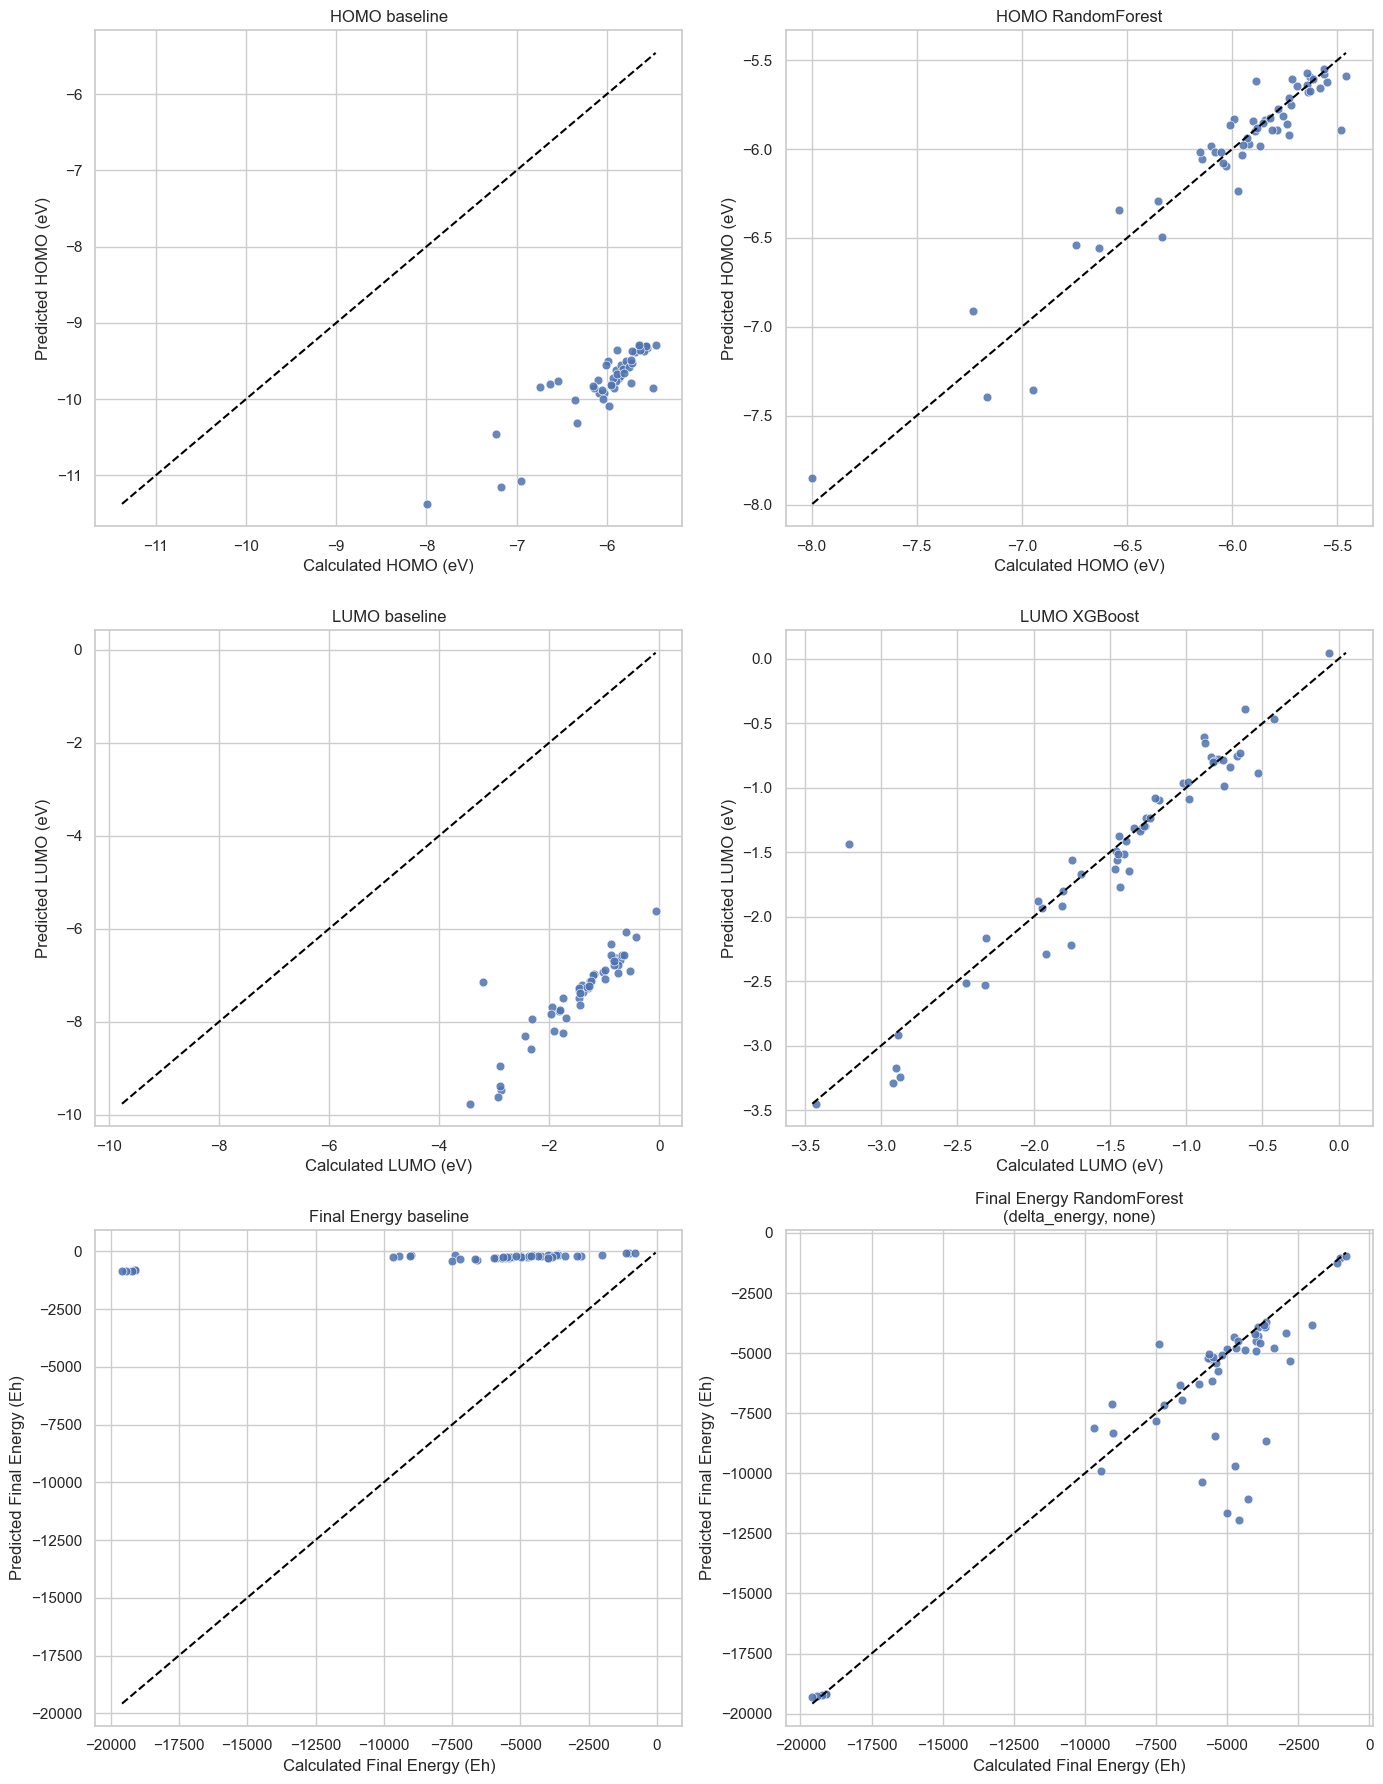

In [168]:
fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

plot_data = [
    ("HOMO baseline", homo_true, homo_xtb, "Calculated HOMO (eV)", "Predicted HOMO (eV)"),
    (f"HOMO {selected_homo_model_name}", homo_true, homo_pred, "Calculated HOMO (eV)", "Predicted HOMO (eV)"),
    ("LUMO baseline", lumo_true, lumo_xtb, "Calculated LUMO (eV)", "Predicted LUMO (eV)"),
    (f"LUMO {selected_lumo_model_name}", lumo_true, lumo_pred, "Calculated LUMO (eV)", "Predicted LUMO (eV)"),
    ("Final Energy baseline", energy_true, energy_xtb, "Calculated Final Energy (Eh)", "Predicted Final Energy (Eh)"),
    (
        f"Final Energy {selected_energy_model_name}\n({selected_energy_target_mode}, {selected_energy_weight_scheme})",
        energy_true,
        energy_pred,
        "Calculated Final Energy (Eh)",
        "Predicted Final Energy (Eh)",
    ),
]

for i, (title, actual_vals, pred_vals, xlabel, ylabel) in enumerate(plot_data):
    ax = axs[i]
    sns.scatterplot(x=actual_vals, y=pred_vals, ax=ax, alpha=0.85, s=40)

    min_val = min(np.min(actual_vals), np.min(pred_vals))
    max_val = max(np.max(actual_vals), np.max(pred_vals))
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="black")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_model_parity_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

## 7.1 Error distributions

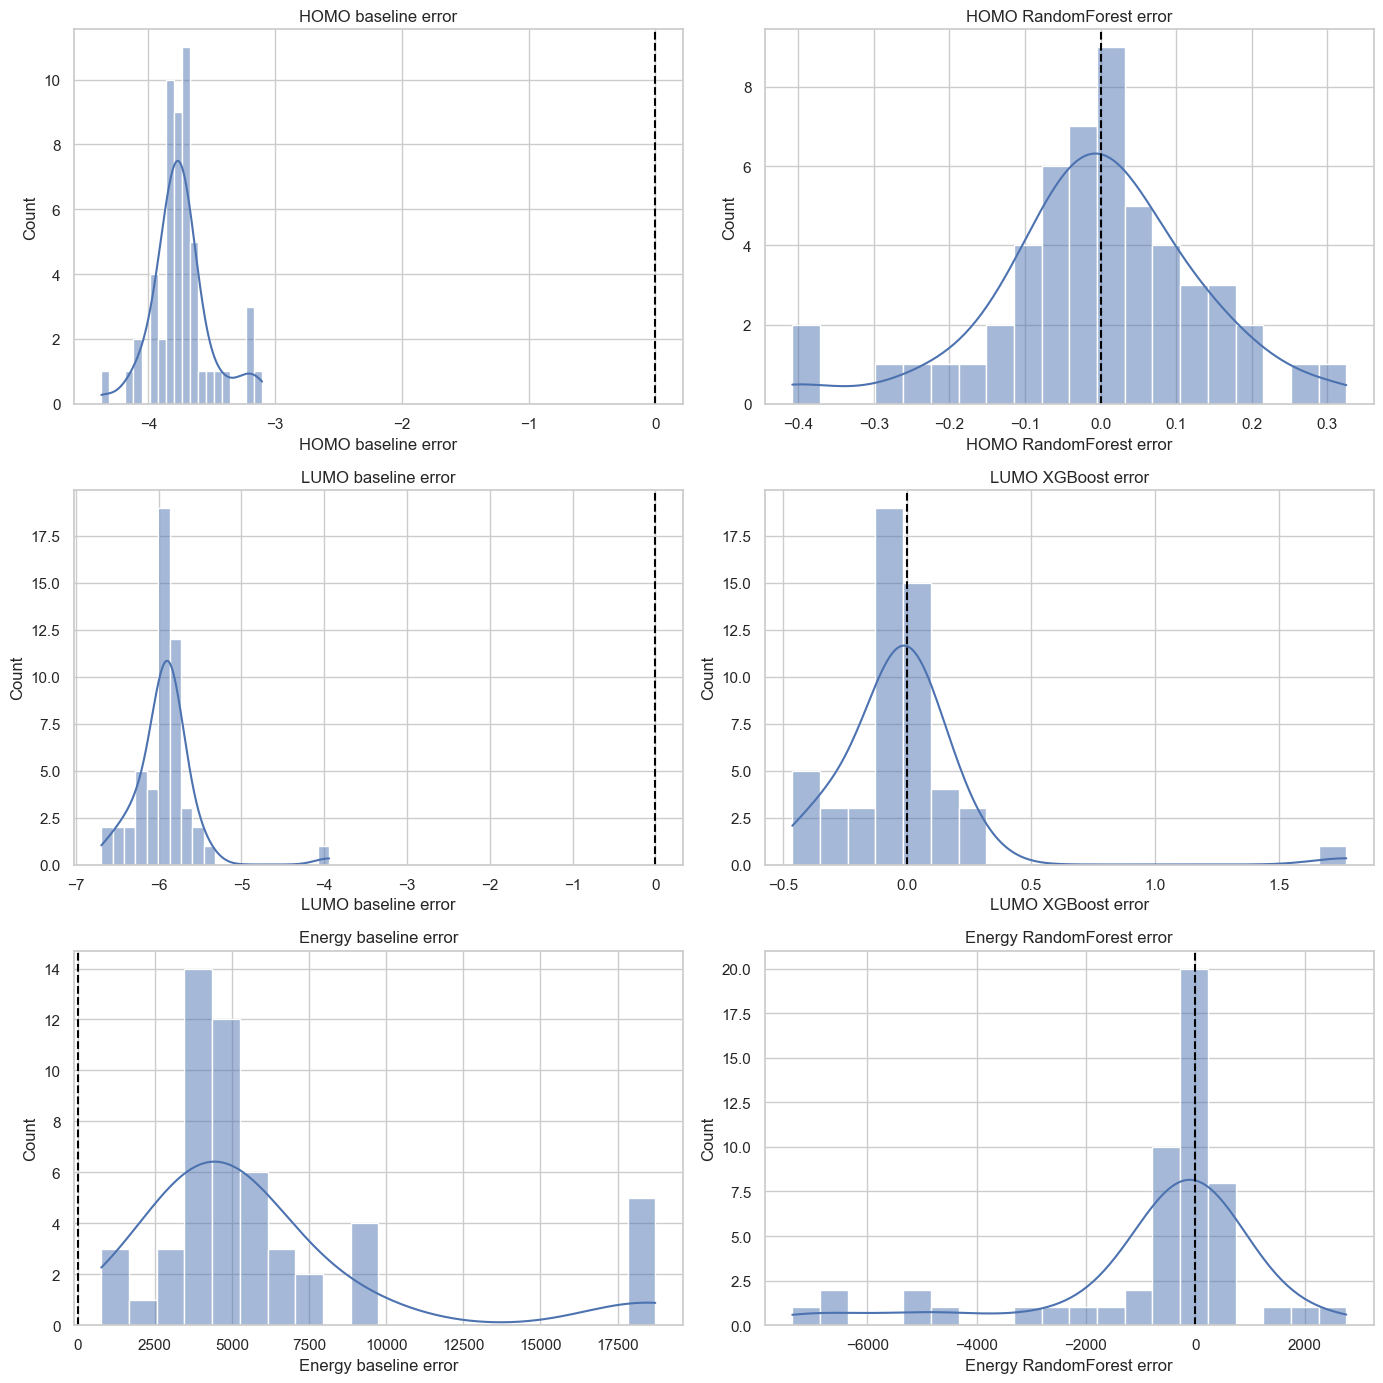

In [169]:
error_df = pd.DataFrame({
    "HOMO baseline error": homo_xtb - homo_true,
    f"HOMO {selected_homo_model_name} error": homo_pred - homo_true,
    "LUMO baseline error": lumo_xtb - lumo_true,
    f"LUMO {selected_lumo_model_name} error": lumo_pred - lumo_true,
    "Energy baseline error": energy_xtb - energy_true,
    f"Energy {selected_energy_model_name} error": energy_pred - energy_true,
})

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(error_df.columns):
    sns.histplot(error_df[col], bins=20, kde=True, ax=axes[i])
    axes[i].axvline(0, linestyle="--", color="black")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 7.2 Residuals vs predictions

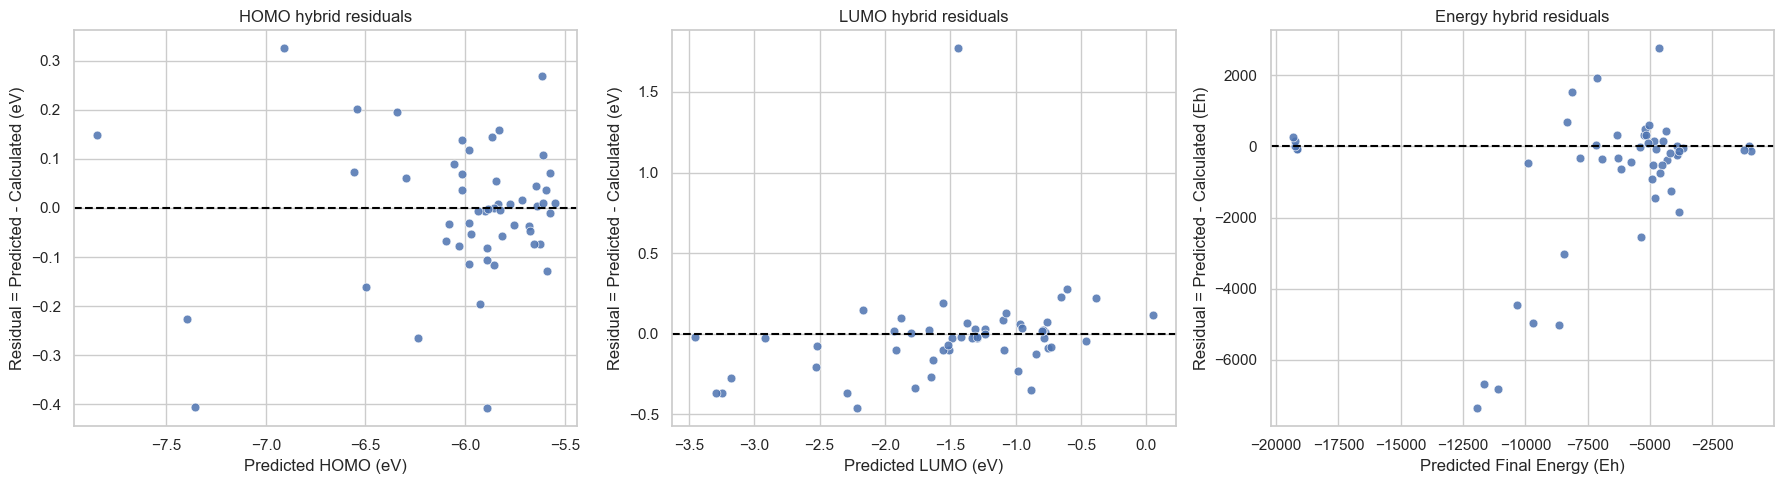

In [170]:
residual_plots = [
    ("HOMO hybrid residuals", homo_pred, homo_pred - homo_true, "Predicted HOMO (eV)", "Residual = Predicted - Calculated (eV)"),
    ("LUMO hybrid residuals", lumo_pred, lumo_pred - lumo_true, "Predicted LUMO (eV)", "Residual = Predicted - Calculated (eV)"),
    ("Energy hybrid residuals", energy_pred, energy_pred - energy_true, "Predicted Final Energy (Eh)", "Residual = Predicted - Calculated (Eh)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, preds, residuals, xlabel, ylabel) in zip(axes, residual_plots):
    sns.scatterplot(x=preds, y=residuals, ax=ax, s=40, alpha=0.85)
    ax.axhline(0, linestyle="--", color="black")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

# 8. Final full-dataset retraining for deployment

In [171]:

full_metadata_df = dataset[metadata_export_cols].copy().reset_index(drop=True)

full_inner_splits = make_object_level_shuffle_splits(
    frame_or_X=X,
    n_splits=N_INNER_SPLITS,
    test_size=INNER_VALID_SIZE,
    random_state=RANDOM_STATE + 90000
)


## HOMO model

In [172]:
deployment_homo_model, deployment_scaler_X_homo, deployment_scaler_y_homo, _, deployment_homo_params, deployment_homo_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_homo,
    X_eval=X,
    model_name=selected_homo_model_name,
    n_trials=MODEL_TRIALS[selected_homo_model_name],
    seed=RANDOM_STATE + 91000,
    inner_splits=full_inner_splits,
    weight_scheme_name=None
)

## LUMO model

In [173]:
deployment_lumo_model, deployment_scaler_X_lumo, deployment_scaler_y_lumo, _, deployment_lumo_params, deployment_lumo_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_lumo,
    X_eval=X,
    model_name=selected_lumo_model_name,
    n_trials=MODEL_TRIALS[selected_lumo_model_name],
    seed=RANDOM_STATE + 92000,
    inner_splits=full_inner_splits,
    weight_scheme_name=None
)

## Energy model

In [174]:
y_energy_full_selected = get_energy_target_for_indices(X.index, selected_energy_target_mode)

deployment_energy_model, deployment_scaler_X_energy, deployment_scaler_y_energy, _, deployment_energy_params, deployment_energy_inner_score = fit_final_model(
    X_fit=X,
    y_fit=y_energy_full_selected,
    X_eval=X,
    model_name=selected_energy_model_name,
    n_trials=MODEL_TRIALS[selected_energy_model_name],
    seed=RANDOM_STATE + 93000,
    inner_splits=full_inner_splits,
    weight_scheme_name=selected_energy_weight_scheme if selected_energy_model_name in WEIGHTED_MODELS else None,
    inner_score_fn=energy_inner_mae_from_restored(selected_energy_target_mode)
)

## Saving

In [175]:
deployment_homo_bundle = {
    "model_name": selected_homo_model_name,
    "target_name": "HOMO",
    "delta_target_name": "delta_homo",
    "feature_columns": features_common,
    "xtb_reference_column": "HOMO_xtb (eV)",
    "target_column": "HOMO_orca (eV)",
    "target_unit": "eV",
    "model": deployment_homo_model,
    "scaler_X": deployment_scaler_X_homo,
    "scaler_y": deployment_scaler_y_homo,
    "best_params": deployment_homo_params,
    "best_inner_score": deployment_homo_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

deployment_lumo_bundle = {
    "model_name": selected_lumo_model_name,
    "target_name": "LUMO",
    "delta_target_name": "delta_lumo",
    "feature_columns": features_common,
    "xtb_reference_column": "LUMO_xtb (eV)",
    "target_column": "LUMO_orca (eV)",
    "target_unit": "eV",
    "model": deployment_lumo_model,
    "scaler_X": deployment_scaler_X_lumo,
    "scaler_y": deployment_scaler_y_lumo,
    "best_params": deployment_lumo_params,
    "best_inner_score": deployment_lumo_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

deployment_energy_bundle = {
    "model_name": selected_energy_model_name,
    "target_name": "Final Energy",
    "feature_columns": features_common,
    "xtb_reference_column": "Total energy xtb (Eh)",
    "target_column": "Final Energy (Eh)",
    "target_unit": "Eh",
    "target_mode": selected_energy_target_mode,
    "weight_scheme_name": selected_energy_weight_scheme,
    "model": deployment_energy_model,
    "scaler_X": deployment_scaler_X_energy,
    "scaler_y": deployment_scaler_y_energy,
    "best_params": deployment_energy_params,
    "best_inner_score": deployment_energy_inner_score,
    "fit_scope": "full_dataset_after_holdout_evaluation",
}

In [176]:
joblib.dump(
    deployment_homo_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_homo_model_name.lower()}_homo_bundle_all_data.pkl")
)

joblib.dump(
    deployment_lumo_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_lumo_model_name.lower()}_lumo_bundle_all_data.pkl")
)

joblib.dump(
    deployment_energy_bundle,
    os.path.join(OUTPUT_DIR, f"deployment_{selected_energy_model_name.lower()}_energy_bundle_all_data.pkl")
)

['./output_within_group_holdout_pruned_v4\\deployment_randomforest_energy_bundle_all_data.pkl']